In [ ]:
import pandas as pd               # Data manipulation and analysis
import numpy as np                # Numerical operations
import requests                    # Fetching data from URLs or APIs
import matplotlib.pyplot as plt    # Data visualization (plots, charts)
import seaborn as sns              # Advanced statistical data visualization
from sklearn.impute import KNNImputer      # Fill missing values using KNN
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Encode categorical vars & standardize features
import warnings                    # Control warning messages

warnings.filterwarnings('ignore')  # Suppress warning messages for cleaner output

# Set clean styling for plots
plt.style.use('default')           # Use Matplotlib's default style
sns.set_palette("Set2")            # Set Seaborn's color palette to 'Set2'

from sklearn.feature_selection import SelectKBest, chi2, f_classif,f_regression,mutual_info_regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from scipy.stats import chi2_contingency

from sklearn.impute import KNNImputer



### Set your environment.

This code sets up the environment for **data analysis, preprocessing, and visualization**:

1. **Library Imports**  
   - **Pandas / NumPy:** For handling and manipulating structured data.  
   - **Requests:** To download or retrieve datasets from the web.  
   - **Matplotlib / Seaborn:** For creating clear, visually appealing plots and charts.  
   - **KNNImputer:** To fill missing values by finding similar data points (K-Nearest Neighbors).  
   - **LabelEncoder / StandardScaler:** For encoding categorical variables into numeric form and standardizing numeric features.

2. **Warning Control**  
   Suppresses warning messages to keep the notebook output clean.

3. **Visualization Styling**  
   Applies a consistent and professional plot style (`default` from Matplotlib) and a color palette (`Set2` from Seaborn) for better readability and aesthetics.


In [2]:
# ===============================================================
#  LOADING THE DATASET + OVERVIEW
# ===============================================================



# Fetch the datataset
# Note: Ensure you have the correct path to the CSV file
# If the file is in the same directory, you can use a relative path.
globalfin = pd.read_csv("GlobalFindexDatabase2025.csv")

# Display the first few rows of the DataFrame 
# named 'globalfin'
globalfin.head()

,countrynewwb,codewb,year,pop_adult,regionwb24_hi,incomegroupwb24,group,group2,account_t_d,fiaccount_t_d,...,con12m_s,con26lm_s,con12w_s,con2f_s,con13_s,con26m_s,con28lm_s,con5a_s,con17c_s,con32h_s
0,Afghanistan,AFG,2011,14575546.0,South Asia (excluding high income),Low income,all,all,0.090050,0.090050,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,ALB,2011,2281010.0,Europe & Central Asia (excluding high income),Upper middle income,all,all,0.282681,0.282681,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Algeria,DZA,2011,26251587.0,Middle East & North Africa (excluding high inc...,Lower middle income,all,all,0.332861,0.332861,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Angola,AGO,2011,12779501.0,Sub-Saharan Africa (excluding high income),Lower middle income,all,all,0.392035,0.392035,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,ARG,2011,30685516.0,Latin America & Caribbean (excluding high income),Upper middle income,all,all,0.331302,0.331302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
## Get an overview of globalfin info, and descriptive statistics
print("shape:", globalfin.shape)
print("duplicates:", globalfin.duplicated().sum())
print("\ncolumns:\n", globalfin.columns.tolist())       
print(globalfin.info())



shape: (8566, 437)
duplicates: 0

columns:
 ['countrynewwb', 'codewb', 'year', 'pop_adult', 'regionwb24_hi', 'incomegroupwb24', 'group', 'group2', 'account_t_d', 'fiaccount_t_d', 'mobileaccount_t_d', 'borrow_any_t_d', 'fin4_d', 'dig_acc', 'fin11_2a', 'fin11a', 'fin11b', 'fin11c', 'fin11f', 'fin11d', 'fin11e', 'fin14a', 'fin14b', 'fin14c', 'fin14d', 'fin13_1a', 'fin13_1b', 'fin26a', 'fin26b', 'fin27a', 'fin27b', 'fin17f', 'fin17a_17a1_d', 'fin17a', 'fin17b', 'fin17c', 'fin22d', 'fin22e', 'fin22a_22a1_22g_d', 'fin22a', 'fin22a_1', 'fin22b', 'fin22c', 'fin24sav', 'fin24fam', 'fin24work', 'fin24bor', 'fin24sell', 'fin24other', 'fin24aVD', 'fin24aSD', 'fin24aND', 'fin24aSD_ND', 'fin24aP', 'fin24aN', 'fin24sav_SD_ND', 'fin24fam_SD_ND', 'fin24work_SD_ND', 'fin24bor_SD_ND', 'fin24sell_SD_ND', 'fin24other_SD_ND', 'fin24sav_VD', 'fin24fam_VD', 'fin24work_VD', 'fin24bor_VD', 'fin24sell_VD', 'fin24other_VD', 'fh1', 'fin28', 'fh2', 'fin29', 'fin31a_31b', 'fin30', 'fin31a', 'fin31b', 'fin31d', 'fin3

In [4]:

print(globalfin.describe(include='all'))
print(globalfin.dtypes)

       countrynewwb codewb         year     pop_adult regionwb24_hi  \
count          8566   8566  8566.000000  7.882000e+03          7882   
unique          174    174          NaN           NaN             7   
top         Albania    ALB          NaN           NaN   High income   
freq             57     57          NaN           NaN          2643   
mean            NaN    NaN  2017.762550  3.798604e+07           NaN   
std             NaN    NaN     4.710102  1.269394e+08           NaN   
min             NaN    NaN  2011.000000  2.280160e+05           NaN   
25%             NaN    NaN  2014.000000  3.749429e+06           NaN   
50%             NaN    NaN  2017.000000  8.517166e+06           NaN   
75%             NaN    NaN  2022.000000  2.590395e+07           NaN   
max             NaN    NaN  2024.000000  1.176679e+09           NaN   

       incomegroupwb24   group group2  account_t_d  fiaccount_t_d  ...  \
count             7882    8566   8566  8476.000000    8384.000000  ...   

In [5]:
# Create a summary DataFrame to show data types, missing values, and unique counts
# summary: dtype / missing / unique
summary = pd.DataFrame({
    'dtype': globalfin.dtypes.astype(str),
    'n_missing': globalfin.isnull().sum(),
    'pct_missing': globalfin.isnull().mean(),
    'n_unique': globalfin.nunique(dropna=False)
})
summary = summary.sort_values('pct_missing', ascending=False)
summary.head(20)   # show top 20 by missingness

,dtype,n_missing,pct_missing,n_unique
con32h_s,float64,8565,0.999883,2
con17c_s,float64,8565,0.999883,2
con5a_s,float64,8565,0.999883,2
fin32_33_34b_s,float64,8565,0.999883,2
con13_s,float64,8565,0.999883,2
con26m_s,float64,8565,0.999883,2
con12m_s,float64,8565,0.999883,2
con28lm_s,float64,8565,0.999883,2
fin37_38_39d_s,float64,8565,0.999883,2
fing2p_card_s,float64,8565,0.999883,2


In [6]:
#Create Working Copy and Basic Cleaning
# Create working copy
df = globalfin.copy()

print(f"Starting with: {df.shape}")
print(f"Target variable 'account_t_d' missing: {df['account_t_d'].isnull().sum()} ({df['account_t_d'].isnull().mean():.1%})")

Starting with: (8566, 437)
Target variable 'account_t_d' missing: 90 (1.1%)


In [7]:
# Create detailed missingness report
def analyze_missingness(df):
    missing_info = pd.DataFrame({
        'column': df.columns,
        'missing_count': df.isnull().sum(),
        'missing_pct': df.isnull().mean() * 100,
        'dtype': df.dtypes.astype(str),
        'unique_values': df.nunique()
    }).sort_values('missing_pct', ascending=False)
    
    return missing_info

missing_report = analyze_missingness(globalfin)
print("Top 20 columns by missingness:")
print(missing_report.head(20))

Top 20 columns by missingness:
                        column  missing_count  missing_pct    dtype  \
con32h_s              con32h_s           8565    99.988326  float64   
con17c_s              con17c_s           8565    99.988326  float64   
con5a_s                con5a_s           8565    99.988326  float64   
fin32_33_34b_s  fin32_33_34b_s           8565    99.988326  float64   
con13_s                con13_s           8565    99.988326  float64   
con26m_s              con26m_s           8565    99.988326  float64   
con12m_s              con12m_s           8565    99.988326  float64   
con28lm_s            con28lm_s           8565    99.988326  float64   
fin37_38_39d_s  fin37_38_39d_s           8565    99.988326  float64   
fing2p_card_s    fing2p_card_s           8565    99.988326  float64   
con26lm_s            con26lm_s           8564    99.976652  float64   
fin32_33_34c_s  fin32_33_34c_s           8564    99.976652  float64   
fin13f_1_s          fin13f_1_s           8563 

In [8]:
# Categorize columns by missingness level
high_missing = missing_report[missing_report['missing_pct'] > 60]['column'].tolist()
med_missing = missing_report[(missing_report['missing_pct'] > 35) & (missing_report['missing_pct'] <= 60)]['column'].tolist()
low_missing = missing_report[missing_report['missing_pct'] <= 45]['column'].tolist()

print(f"High missingness (>60%): {len(high_missing)} columns")
print(f"Medium missingness (35-60%): {len(med_missing)} columns") 
print(f"Low missingness (<35%): {len(low_missing)} columns")

# Remove high missingness columns (>90% missing)
print(f"\nRemoving {len(high_missing)} high-missingness columns")
df_clean = globalfin.drop(columns=high_missing)
print(f"New shape: {df_clean.shape}")

High missingness (>60%): 399 columns
Medium missingness (35-60%): 15 columns
Low missingness (<35%): 26 columns

Removing 399 high-missingness columns
New shape: (8566, 38)


In [9]:
#Identify Potential Leakage Variables
# Look for variables that might leak information about the target
# These often have names suggesting they measure financial behavior
potential_leakage = []

for col in df_clean.columns:
    if col != 'account_t_d':
        # Check correlation with target (high correlation might indicate leakage)
        if df_clean[col].dtype in ['float64', 'int64']:
            corr = df_clean[col].corr(df_clean['account_t_d'])
            if abs(corr) > 0.7:  # Very high correlation
                potential_leakage.append((col, corr))

print("Potential data leakage candidates (high correlation with target):")
for col, corr in sorted(potential_leakage, key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"{col}: correlation = {corr:.4f}")



Potential data leakage candidates (high correlation with target):
fiaccount_t_d: correlation = 0.9591
g20_any: correlation = 0.9551
g20_made: correlation = 0.8951
fin2_t_d: correlation = 0.8950
g20_received: correlation = 0.8936
fin31a_31b: correlation = 0.7796
fin17a: correlation = 0.7600
fin17a_17a1_d: correlation = 0.7564
fin32_acc: correlation = 0.7544
fin34a: correlation = 0.7460


In [10]:
# Define target variable
target = 'account_t_d'

# Identify highly correlated features (potential leakage)
high_corr_features = []

for col in df_clean.columns:
    if col != target and df_clean[col].dtype in ['float64', 'int64']:
        corr = df_clean[col].corr(df_clean[target])
        if abs(corr) > 0.80:  # threshold for leakage
            high_corr_features.append((col, corr))

# Sort by absolute correlation
high_corr_features = sorted(high_corr_features, key=lambda x: abs(x[1]), reverse=True)

print("Dropping features highly correlated with target (>0.80):")
for col, corr in high_corr_features:
    print(f"{col}: correlation = {corr:.4f}")

# Drop them from dataset
df_clean = df_clean.drop(columns=[col for col, _ in high_corr_features])


Dropping features highly correlated with target (>0.80):
fiaccount_t_d: correlation = 0.9591
g20_any: correlation = 0.9551
g20_made: correlation = 0.8951
fin2_t_d: correlation = 0.8950
g20_received: correlation = 0.8936


In [11]:
df_clean.shape

(8566, 33)

In [12]:
# Identify feature types for different preprocessing approaches
def categorize_features(df, target_col='account_t_d'):
    features = {}
    
    # Exclude target from feature analysis
    feature_cols = [col for col in df.columns if col != target_col]
    
    # Numerical features
    numerical = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    
    # Categorical features
    categorical = df[feature_cols].select_dtypes(include=['object']).columns.tolist()
    
    # Binary-like features (assuming 0/1 or True/False)
    binary_candidates = []
    for col in numerical:
        unique_vals = df[col].dropna().unique()
        if len(unique_vals) <= 2 and all(val in [0, 1, 0.0, 1.0] for val in unique_vals):
            binary_candidates.append(col)
    
    features['numerical'] = [col for col in numerical if col not in binary_candidates]
    features['binary'] = binary_candidates
    features['categorical'] = categorical
    
    return features

feature_types = categorize_features(df_clean)

print("Feature categorization:")
for ftype, cols in feature_types.items():
    print(f"{ftype.upper()}: {len(cols)} features")
    if len(cols) <= 10:  # Show column names if not too many
        print(f"  {cols}")
    print()

Feature categorization:
NUMERICAL: 26 features

BINARY: 0 features
  []

CATEGORICAL: 6 features
  ['countrynewwb', 'codewb', 'regionwb24_hi', 'incomegroupwb24', 'group', 'group2']



In [13]:

# Columns to remove (metadata that shouldn't be used for prediction)
metadata_cols = [
    'countrynewwb',  # Country name (text)
    'codewb',        # Country code  
    'year',          # Year (could cause data leakage)
    'pop_adult'      # Population size (not individual-level)
]

# Check if these columns exist before dropping
existing_metadata = [col for col in metadata_cols if col in df.columns]
df_clean = df_clean.drop(columns=existing_metadata)

print(f"Removed {len(existing_metadata)} metadata columns")
print(f"New shape: {df_clean.shape}")


Removed 4 metadata columns
New shape: (8566, 29)


In [14]:
# Summary of cleaned dataset
print("=== CLEANED DATASET SUMMARY ===")
print(f"Shape: {df_clean.shape}")
print(f"Target variable: account_t_d")
print(f"Target missing: {df_clean['account_t_d'].isnull().sum()} ({df_clean['account_t_d'].isnull().mean():.1%})")

print(f"\nFeature types:")
for ftype, cols in feature_types.items():
    print(f"  {ftype}: {len(cols)} features")

print(f"\nOverall missingness:")
total_missing_pct = df_clean.isnull().mean().mean() * 100
print(f"  Average: {total_missing_pct:.1f}%")

=== CLEANED DATASET SUMMARY ===
Shape: (8566, 29)
Target variable: account_t_d
Target missing: 90 (1.1%)

Feature types:
  numerical: 26 features
  binary: 0 features
  categorical: 6 features

Overall missingness:
  Average: 36.0%


In [15]:
df_clean.columns

Index(['regionwb24_hi', 'incomegroupwb24', 'group', 'group2', 'account_t_d',
       'borrow_any_t_d', 'fin17a_17a1_d', 'fin17a', 'fin22d',
       'fin22a_22a1_22g_d', 'fin22a', 'fin22b', 'fin24aP', 'fin24aN',
       'fin31a_31b', 'fin30', 'fin31d', 'fin32_n33_acc', 'fin32_n33', 'fin32',
       'fin32_acc', 'fin34a', 'fin37_38', 'fin37', 'fin42', 'fin10',
       'fing2p_fin', 'fing2p', 'save_any_t_d'],
      dtype='object')

In [16]:
rename_map = {
    "regionwb24_hi": "WorldBank_Region",
    "incomegroupwb24": "Income_Group",
    "group": "Group",
    "group2": "Group2",
    "account_t_d": "Has_Account",
    "borrow_any_t_d": "Borrowed_Any",
    "fin17a_17a1_d": "Borrow_Source_Type",
    "fin17a": "Borrowed_from_Financial_Institution",
    "fin22d": "Used_Mobile_Money_for_Utility",
    "fin22a_22a1_22g_d": "Digital_Payment_Type",
    "fin22a": "Made_Digital_Payment",
    "fin22b": "Received_Digital_Payment",
    "fin24aP": "Saved_at_Financial_Institution",
    "fin24aN": "Saved_at_Other_Place",
    "fin31a_31b": "Paid_Utility_or_School_Fees",
    "fin30": "Used_Only_Cash_for_Electricity",
    "fin31d": "Made_Digital_Government_Payment",
    "fin32_n33_acc": "Has_Credit_Card_or_Loan",
    "fin32_n33": "Outstanding_Credit",
    "fin32": "Has_Credit_Card",
    "fin32_acc": "Outstanding_Credit_with_Account",
    "fin34a": "Mortgage_or_Housing_Loan",
    "fin37_38": "Health_or_Education_Expense_Loan",
    "fin37": "Borrowed_for_Health",
    "fin42": "Borrowed_for_Education",
    "fin10": "Owns_Credit_Card",
    "fing2p_fin": "Insurance_Product_Use",
    "fing2p": "Has_Insurance",
    "save_any_t_d": "Saved_Any"
}


# Apply renaming
df_clean = df_clean.rename(columns=rename_map)
df_clean.columns

Index(['WorldBank_Region', 'Income_Group', 'Group', 'Group2', 'Has_Account',
       'Borrowed_Any', 'Borrow_Source_Type',
       'Borrowed_from_Financial_Institution', 'Used_Mobile_Money_for_Utility',
       'Digital_Payment_Type', 'Made_Digital_Payment',
       'Received_Digital_Payment', 'Saved_at_Financial_Institution',
       'Saved_at_Other_Place', 'Paid_Utility_or_School_Fees',
       'Used_Only_Cash_for_Electricity', 'Made_Digital_Government_Payment',
       'Has_Credit_Card_or_Loan', 'Outstanding_Credit', 'Has_Credit_Card',
       'Outstanding_Credit_with_Account', 'Mortgage_or_Housing_Loan',
       'Health_or_Education_Expense_Loan', 'Borrowed_for_Health',
       'Borrowed_for_Education', 'Owns_Credit_Card', 'Insurance_Product_Use',
       'Has_Insurance', 'Saved_Any'],
      dtype='object')

In [17]:
# Create a summary DataFrame to show data types, missing values, and unique counts
# summary: dtype / missing / unique
summary = pd.DataFrame({
    'dtype': df_clean.dtypes.astype(str),
    'n_missing': df_clean.isnull().sum(),
    'pct_missing': df_clean.isnull().mean(),
    'n_unique': df_clean.nunique(dropna=False)
})
summary = summary.sort_values('pct_missing', ascending=False)
summary.head(30)   # show top 20 by missingness

,dtype,n_missing,pct_missing,n_unique
Borrowed_for_Education,float64,5059,0.590591,3412
Health_or_Education_Expense_Loan,float64,5033,0.587555,3533
Has_Credit_Card_or_Loan,float64,5031,0.587322,3532
Insurance_Product_Use,float64,4949,0.577749,3616
Borrowed_for_Health,float64,4703,0.549031,3863
Paid_Utility_or_School_Fees,float64,4627,0.540159,3937
Mortgage_or_Housing_Loan,float64,4621,0.539458,3944
Has_Insurance,float64,4547,0.530820,4019
Used_Mobile_Money_for_Utility,float64,4539,0.529886,4027
Owns_Credit_Card,float64,4355,0.508405,4163


In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8566 entries, 0 to 8565
Data columns (total 29 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   WorldBank_Region                     7882 non-null   object 
 1   Income_Group                         7882 non-null   object 
 2   Group                                8566 non-null   object 
 3   Group2                               8566 non-null   object 
 4   Has_Account                          8476 non-null   float64
 5   Borrowed_Any                         6401 non-null   float64
 6   Borrow_Source_Type                   6191 non-null   float64
 7   Borrowed_from_Financial_Institution  5711 non-null   float64
 8   Used_Mobile_Money_for_Utility        4027 non-null   float64
 9   Digital_Payment_Type                 4955 non-null   float64
 10  Made_Digital_Payment                 4602 non-null   float64
 11  Received_Digital_Payment      

In [19]:
print(df_clean.columns)

Index(['WorldBank_Region', 'Income_Group', 'Group', 'Group2', 'Has_Account',
       'Borrowed_Any', 'Borrow_Source_Type',
       'Borrowed_from_Financial_Institution', 'Used_Mobile_Money_for_Utility',
       'Digital_Payment_Type', 'Made_Digital_Payment',
       'Received_Digital_Payment', 'Saved_at_Financial_Institution',
       'Saved_at_Other_Place', 'Paid_Utility_or_School_Fees',
       'Used_Only_Cash_for_Electricity', 'Made_Digital_Government_Payment',
       'Has_Credit_Card_or_Loan', 'Outstanding_Credit', 'Has_Credit_Card',
       'Outstanding_Credit_with_Account', 'Mortgage_or_Housing_Loan',
       'Health_or_Education_Expense_Loan', 'Borrowed_for_Health',
       'Borrowed_for_Education', 'Owns_Credit_Card', 'Insurance_Product_Use',
       'Has_Insurance', 'Saved_Any'],
      dtype='object')


🔗 TOP PREDICTORS:
Paid_Utility_or_School_Fees            0.779630
Borrowed_from_Financial_Institution    0.760001
Borrow_Source_Type                     0.756438
Outstanding_Credit_with_Account        0.754379
Mortgage_or_Housing_Loan               0.745977
Has_Credit_Card_or_Loan                0.729084
Insurance_Product_Use                  0.707995
Has_Credit_Card                        0.700411
Digital_Payment_Type                   0.688059
Made_Digital_Payment                   0.669476
Owns_Credit_Card                       0.668693
Has_Insurance                          0.667195
Outstanding_Credit                     0.663500
Health_or_Education_Expense_Loan       0.584456
Used_Only_Cash_for_Electricity         0.577625
Saved_Any                              0.558575
Borrowed_for_Health                    0.484799
Borrowed_for_Education                 0.392531
Saved_at_Other_Place                   0.344539
Saved_at_Financial_Institution         0.299455
dtype: float64


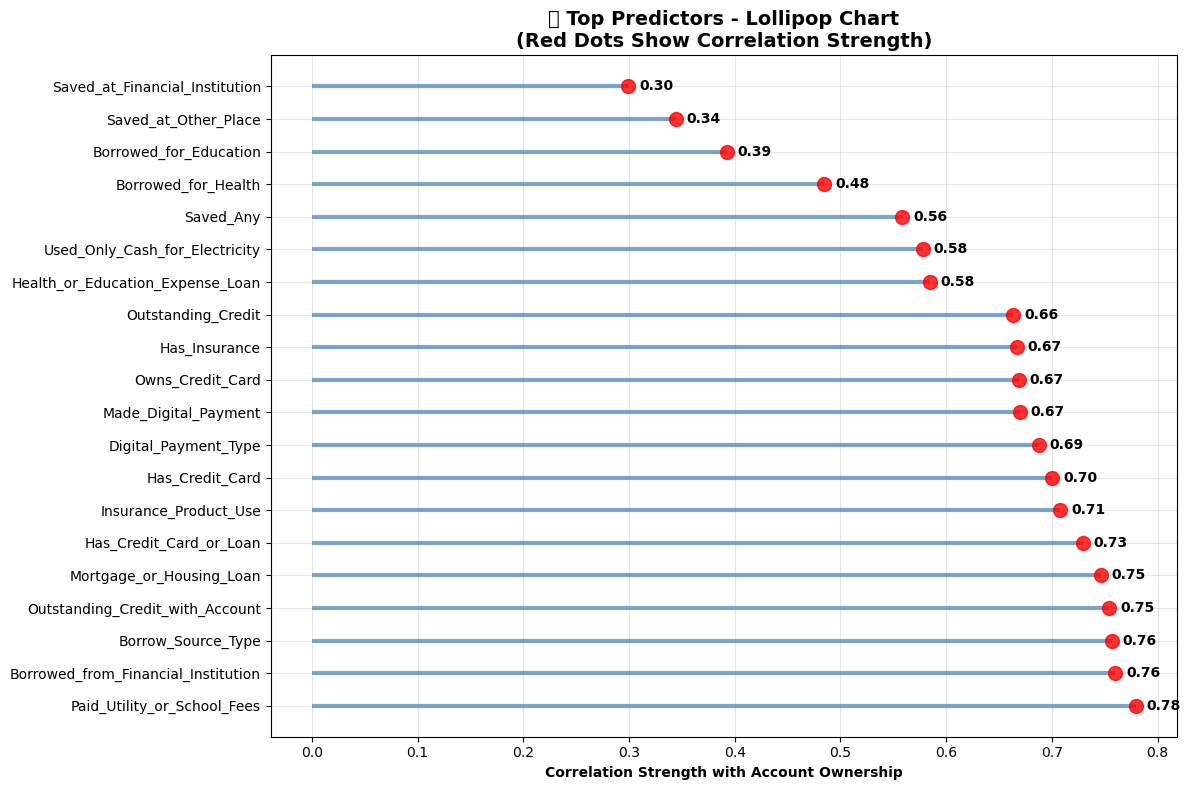

In [20]:
# ===============================================================
# 4. TOP PREDICTORS - What matters most?
# ===============================================================

numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
correlations = df_clean[numerical_cols].corrwith(df_clean['Has_Account']).abs().sort_values(ascending=False)
top_predictors = correlations.drop('Has_Account').head(20)

plt.figure(figsize=(12, 8))
y_pos = np.arange(len(top_predictors))

# Create lollipop chart
plt.hlines(y_pos, 0, top_predictors.values, colors='steelblue', alpha=0.7, linewidth=3)
plt.scatter(top_predictors.values, y_pos, color='red', s=100, alpha=0.8, zorder=5)

plt.yticks(y_pos, top_predictors.index)
plt.xlabel('Correlation Strength with Account Ownership', fontweight='bold')
plt.title('🍭 Top Predictors - Lollipop Chart\n(Red Dots Show Correlation Strength)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(top_predictors.values):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout()


print("🔗 TOP PREDICTORS:")
print(top_predictors.round(7))


In [21]:

def analyze_missing_patterns(df):
    """Analyze missing value patterns in the dataset"""
    print("=== MISSING VALUE ANALYSIS ===")
    print(f"Dataset shape: {df.shape}")
    print(f"\nTotal missing values: {df.isnull().sum().sum()}")
    print(f"Percentage of missing values: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")
    
    # Missing values by column
    missing_info = pd.DataFrame({
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
    })
    missing_info = missing_info[missing_info['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
    print(f"\nColumns with missing values:\n{missing_info}")
    
    return missing_info

def clean_financial_data(df_clean):
    """
    Comprehensive data cleaning pipeline for financial inclusion dataset
    """
    print("Starting data cleaning pipeline...")
    df = df_clean.copy()
    
    # 1. Analyze missing patterns
    missing_info = analyze_missing_patterns(df)
    
    # 2. Handle columns with extreme missingness (>50%)
    high_missing_cols = missing_info[missing_info['Missing_Percentage'] > 55].index.tolist()
    print(f"\n=== HANDLING HIGH MISSINGNESS COLUMNS (>55%) ===")
    print(f"Columns to consider for removal: {high_missing_cols}")
    
    # For financial data, these high-missing columns might represent specialized products
    # Let's create binary indicators for "data availability" before imputation
    for col in high_missing_cols:
        if col in df.columns:
            df[f'{col}_Available'] = (~df[col].isna()).astype(int)
            print(f"Created availability indicator for {col}")
    
    # 3. Separate categorical and numerical columns
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"\n=== COLUMN TYPES ===")
    print(f"Categorical columns: {categorical_cols}")
    print(f"Numerical columns: {len(numerical_cols)} columns")
    
    # 4. Handle categorical variables
    print(f"\n=== CLEANING CATEGORICAL VARIABLES ===")
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            # Fill missing categorical values with 'Unknown'
            df[col] = df[col].fillna('Unknown')
            print(f"Filled missing values in {col} with 'Unknown'")
    
    # 5. Handle numerical variables - different strategies based on missing percentage
    print(f"\n=== CLEANING NUMERICAL VARIABLES ===")
    
    # Strategy 1: Forward fill for columns with <25% missing (likely sequential data)
    low_missing_num = [col for col in numerical_cols if df[col].isnull().sum()/len(df) < 0.25]
    for col in low_missing_num:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
            print(f"Median imputed {col} (low missing: {df[col].isnull().sum()})")
    
    # Strategy 2: KNN imputation for moderate missing (25-55%)
    moderate_missing_num = [col for col in numerical_cols 
                           if 0.25 <= df[col].isnull().sum()/len(df) <= 0.55]
    
    if moderate_missing_num:
        print(f"\nApplying KNN imputation to moderate missing columns: {moderate_missing_num}")
        # Use KNN imputation with k=5
        imputer = KNNImputer(n_neighbors=5)
        df[moderate_missing_num] = imputer.fit_transform(df[moderate_missing_num])
        print("KNN imputation completed")
    
    # Strategy 3: Domain-specific imputation for high missing (>55%)
    high_missing_num = [col for col in numerical_cols 
                       if df[col].isnull().sum()/len(df) > 0.55]
    
    for col in high_missing_num:
        if col in df.columns:
            # For financial products, missing often means "not applicable" or "no usage"
            # Fill with 0 for most financial behavior variables
            df[col] = df[col].fillna(0)
            print(f"Filled {col} missing values with 0 (assumed no usage/participation)")
    
    # 6. Data validation and type optimization
    print(f"\n=== DATA VALIDATION & OPTIMIZATION ===")
    
    # Ensure binary variables are truly binary (0 or 1)
    potential_binary_cols = [col for col in numerical_cols 
                            if df[col].nunique() <= 3 and col != 'Has_Account']
    
    for col in potential_binary_cols:
        unique_vals = sorted(df[col].dropna().unique())
        print(f"{col} unique values: {unique_vals}")
        
        # If values are already 0/1, keep as is
        # If values are like 1/2, convert to 0/1
        if len(unique_vals) == 2 and set(unique_vals) == {1, 2}:
            df[col] = df[col].map({1: 0, 2: 1})
            print(f"Converted {col} from 1/2 to 0/1 encoding")
    
    # Convert appropriate columns to more efficient data types
    for col in numerical_cols:
        if df[col].nunique() <= 2:
            df[col] = df[col].astype('int8')
        elif df[col].nunique() <= 10:
            df[col] = df[col].astype('int16')
    
    # 7. Feature engineering opportunities
    print(f"\n=== FEATURE ENGINEERING ===")
    
    # Create financial activity score
    financial_activity_cols = [col for col in df.columns 
                              if any(keyword in col.lower() for keyword in 
                                   ['borrowed', 'saved', 'payment', 'credit', 'loan'])]
    
    if len(financial_activity_cols) > 0:
        df['Financial_Activity_Score'] = df[financial_activity_cols].sum(axis=1)
        print(f"Created Financial_Activity_Score from {len(financial_activity_cols)} columns")
    
    # Create digital engagement score
    digital_cols = [col for col in df.columns 
                   if 'digital' in col.lower() or 'mobile' in col.lower()]
    
    if len(digital_cols) > 0:
        df['Digital_Engagement_Score'] = df[digital_cols].sum(axis=1)
        print(f"Created Digital_Engagement_Score from {len(digital_cols)} columns")
    
    # 8. Final validation
    print(f"\n=== FINAL VALIDATION ===")
    print(f"Final dataset shape: {df.shape}")
    print(f"Remaining missing values: {df.isnull().sum().sum()}")
    
    if df.isnull().sum().sum() > 0:
        remaining_missing = df.isnull().sum()[df.isnull().sum() > 0]
        print(f"Columns still with missing values:\n{remaining_missing}")
    else:
        print("✅ No missing values remaining!")
    
    # Memory usage optimization
    memory_before = df_clean.memory_usage(deep=True).sum() / 1024**2
    memory_after = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage: {memory_before:.2f}MB → {memory_after:.2f}MB")
    
    return df

def create_data_quality_report(df_original, df_cleaned):
    """Create a comprehensive data quality report"""
    print("\n" + "="*50)
    print("DATA QUALITY REPORT")
    print("="*50)
    
    # Shape comparison
    print(f"Shape before: {df_original.shape}")
    print(f"Shape after: {df_cleaned.shape}")
    
    # Missing values comparison
    missing_before = df_original.isnull().sum().sum()
    missing_after = df_cleaned.isnull().sum().sum()
    print(f"\nMissing values before: {missing_before}")
    print(f"Missing values after: {missing_after}")
    print(f"Missing values reduced by: {missing_before - missing_after}")
    
    # Data type summary
    print(f"\nData types in cleaned dataset:")
    print(df_cleaned.dtypes.value_counts())
    
    # # Target variable distribution
    # if 'Has_Account' in df_cleaned.columns:
    #     target_dist = df_cleaned['Has_Account'].value_counts(normalize=True)
    #     print(f"\nTarget variable (Has_Account) distribution:")
    #     for val, pct in target_dist.items():
    #         print(f"  {val}: {pct:.3f} ({pct*100:.1f}%)")
    
    return df_cleaned

In [22]:
# Apply cleaning pipeline
df_missing = analyze_missing_patterns(df_clean)

=== MISSING VALUE ANALYSIS ===
Dataset shape: (8566, 29)

Total missing values: 89540
Percentage of missing values: 36.04%

Columns with missing values:
                                     Missing_Count  Missing_Percentage
Borrowed_for_Education                        5059           59.059071
Health_or_Education_Expense_Loan              5033           58.755545
Has_Credit_Card_or_Loan                       5031           58.732197
Insurance_Product_Use                         4949           57.774924
Borrowed_for_Health                           4703           54.903105
Paid_Utility_or_School_Fees                   4627           54.015877
Mortgage_or_Housing_Loan                      4621           53.945832
Has_Insurance                                 4547           53.081952
Used_Mobile_Money_for_Utility                 4539           52.988559
Owns_Credit_Card                              4355           50.840532
Outstanding_Credit_with_Account               4169           48.66

In [23]:
df_cleaned = clean_financial_data(df_clean)

Starting data cleaning pipeline...
=== MISSING VALUE ANALYSIS ===
Dataset shape: (8566, 29)

Total missing values: 89540
Percentage of missing values: 36.04%

Columns with missing values:
                                     Missing_Count  Missing_Percentage
Borrowed_for_Education                        5059           59.059071
Health_or_Education_Expense_Loan              5033           58.755545
Has_Credit_Card_or_Loan                       5031           58.732197
Insurance_Product_Use                         4949           57.774924
Borrowed_for_Health                           4703           54.903105
Paid_Utility_or_School_Fees                   4627           54.015877
Mortgage_or_Housing_Loan                      4621           53.945832
Has_Insurance                                 4547           53.081952
Used_Mobile_Money_for_Utility                 4539           52.988559
Owns_Credit_Card                              4355           50.840532
Outstanding_Credit_with_Account

In [24]:
df_report = create_data_quality_report(df_clean,df_cleaned)


DATA QUALITY REPORT
Shape before: (8566, 29)
Shape after: (8566, 35)

Missing values before: 89540
Missing values after: 0
Missing values reduced by: 89540

Data types in cleaned dataset:
float64    27
object      4
int8        4
Name: count, dtype: int64


In [25]:
df_cleaned.columns

Index(['WorldBank_Region', 'Income_Group', 'Group', 'Group2', 'Has_Account',
       'Borrowed_Any', 'Borrow_Source_Type',
       'Borrowed_from_Financial_Institution', 'Used_Mobile_Money_for_Utility',
       'Digital_Payment_Type', 'Made_Digital_Payment',
       'Received_Digital_Payment', 'Saved_at_Financial_Institution',
       'Saved_at_Other_Place', 'Paid_Utility_or_School_Fees',
       'Used_Only_Cash_for_Electricity', 'Made_Digital_Government_Payment',
       'Has_Credit_Card_or_Loan', 'Outstanding_Credit', 'Has_Credit_Card',
       'Outstanding_Credit_with_Account', 'Mortgage_or_Housing_Loan',
       'Health_or_Education_Expense_Loan', 'Borrowed_for_Health',
       'Borrowed_for_Education', 'Owns_Credit_Card', 'Insurance_Product_Use',
       'Has_Insurance', 'Saved_Any', 'Borrowed_for_Education_Available',
       'Health_or_Education_Expense_Loan_Available',
       'Has_Credit_Card_or_Loan_Available', 'Insurance_Product_Use_Available',
       'Financial_Activity_Score', 'Digital

🔗 TOP PREDICTORS:
Borrow_Source_Type                     0.653667
Borrowed_from_Financial_Institution    0.652478
Paid_Utility_or_School_Fees            0.650599
Outstanding_Credit_with_Account        0.649444
Mortgage_or_Housing_Loan               0.647203
Digital_Payment_Type                   0.598015
Made_Digital_Payment                   0.594731
Financial_Activity_Score               0.592681
Has_Credit_Card                        0.584775
Owns_Credit_Card                       0.572216
Outstanding_Credit                     0.570117
Has_Credit_Card_or_Loan                0.566566
Has_Insurance                          0.543709
Insurance_Product_Use                  0.540821
Saved_Any                              0.496243
Used_Only_Cash_for_Electricity         0.478416
Has_Credit_Card_or_Loan_Available      0.444464
Borrowed_for_Health                    0.438741
Insurance_Product_Use_Available        0.394548
Health_or_Education_Expense_Loan       0.370453
dtype: float64


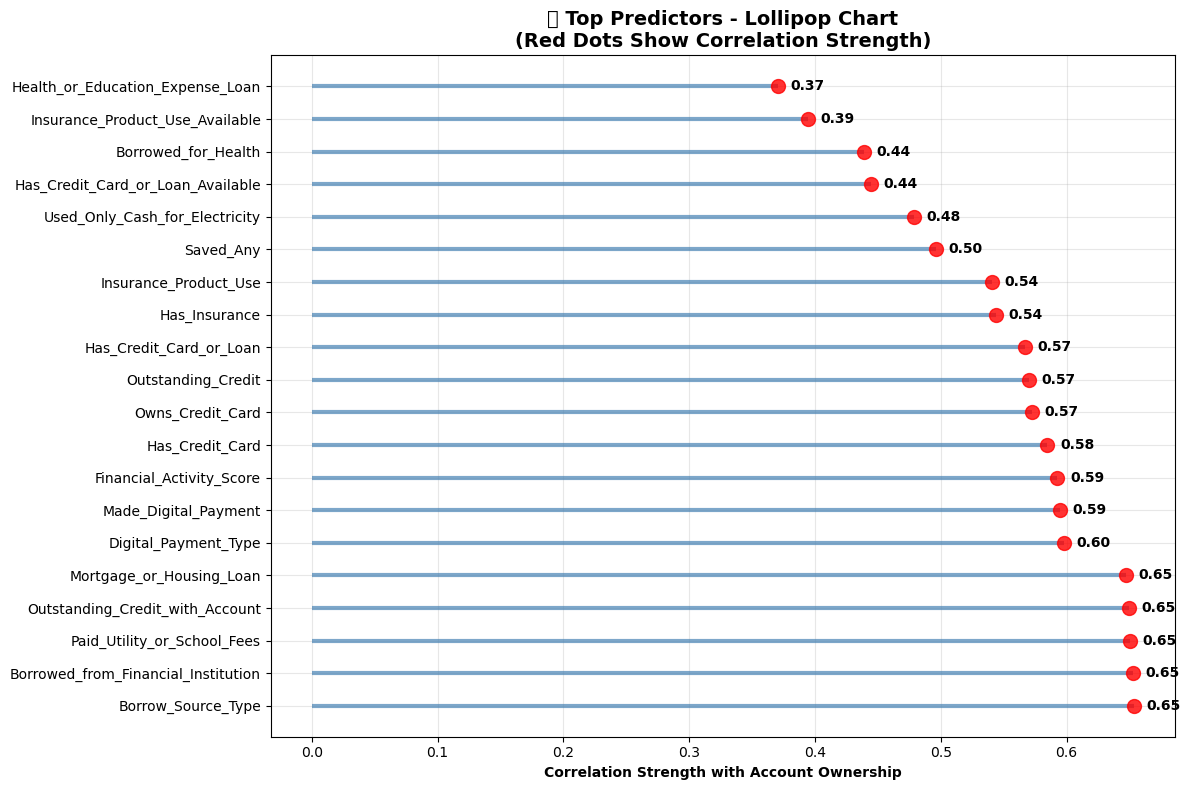

In [26]:
# ===============================================================
# 4. TOP PREDICTORS - What matters most?
# ===============================================================

numerical_cols = df_cleaned.select_dtypes(include=[np.number]).columns
correlations = df_cleaned[numerical_cols].corrwith(df_cleaned['Has_Account']).abs().sort_values(ascending=False)
top_predictors = correlations.drop('Has_Account').head(20)

plt.figure(figsize=(12, 8))
y_pos = np.arange(len(top_predictors))

# Create lollipop chart
plt.hlines(y_pos, 0, top_predictors.values, colors='steelblue', alpha=0.7, linewidth=3)
plt.scatter(top_predictors.values, y_pos, color='red', s=100, alpha=0.8, zorder=5)

plt.yticks(y_pos, top_predictors.index)
plt.xlabel('Correlation Strength with Account Ownership', fontweight='bold')
plt.title('🍭 Top Predictors - Lollipop Chart\n(Red Dots Show Correlation Strength)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(top_predictors.values):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout()


print("🔗 TOP PREDICTORS:")
print(top_predictors.round(7))


In [28]:
target = df_cleaned['Has_Account']
target.head(15)

0     0.090050
1     0.282681
2     0.332861
3     0.392035
4     0.331302
5     0.174869
6     0.990648
7     0.970817
8     0.149009
9     0.645146
10    0.317436
11    0.586020
12    0.963061
13    0.104639
14    0.280291
Name: Has_Account, dtype: float64

In [ ]:



def select_optimal_variables(df, target_col='Has_Account', max_variables=30):
    """
    Multi-method variable selection for financial account prediction
    """
    print("🏦 FINANCIAL ACCOUNT PREDICTION: VARIABLE SELECTION")
    print("="*60)
    
    # Prepare the data
    y = df[target_col]
    X = df.drop(columns=[target_col])
    
    # Handle categorical variables
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"📊 Dataset Overview:")
    print(f"   • Total variables available: {X.shape[1]}")
    print(f"   • Numerical variables: {len(numerical_cols)}")
    print(f"   • Categorical variables: {len(categorical_cols)}")
    print(f"   • Target to select: {max_variables} variables")
    
    # Encode categorical variables for analysis
    X_encoded = X.copy()
    label_encoders = {}
    
    for col in categorical_cols:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        label_encoders[col] = le
    
    print(f"\n🔍 SELECTION METHODS:")
    
    # Method 1: Correlation with target
    print("\n1️⃣  CORRELATION ANALYSIS")
    correlations = X_encoded.corrwith(y).abs().sort_values(ascending=False)
    top_corr_vars = correlations.head(max_variables).index.tolist()
    print(f"   Top 10 by correlation:")
    for i, (var, corr) in enumerate(correlations.head(10).items(), 1):
        print(f"   {i:2}. {var:<35} {corr:.3f}")
    
    # Method 2: Mutual Information
    print("\n2️⃣  MUTUAL INFORMATION ANALYSIS")
    mi_scores = mutual_info_regression(X_encoded, y, random_state=42)
    mi_df = pd.DataFrame({'variable': X_encoded.columns, 'mi_score': mi_scores})
    mi_df = mi_df.sort_values('mi_score', ascending=False)
    top_mi_vars = mi_df.head(max_variables)['variable'].tolist()
    print(f"   Top 10 by mutual information:")
    for i, row in mi_df.head(10).iterrows():
        print(f"   {i+1:2}. {row['variable']:<35} {row['mi_score']:.3f}")
    
    # Method 3: Random Forest Feature Importance
    print("\n3️⃣  RANDOM FOREST IMPORTANCE")
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_encoded, y)
    
    rf_importance = pd.DataFrame({
        'variable': X_encoded.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    top_rf_vars = rf_importance.head(max_variables)['variable'].tolist()
    print(f"   Top 10 by RF importance:")
    for i, row in rf_importance.head(10).iterrows():
        print(f"   {i+1:2}. {row['variable']:<35} {row['importance']:.3f}")
    
    # Method 4: Domain Knowledge Ranking
    print("\n4️⃣  DOMAIN KNOWLEDGE PRIORITIZATION")
    
    # Define variable importance categories based on financial inclusion domain
    high_priority = [
        # Core financial services
        'Borrowed_from_Financial_Institution', 'Saved_at_Financial_Institution',
        'Has_Credit_Card', 'Owns_Credit_Card', 'Outstanding_Credit',
        'Mortgage_or_Housing_Loan', 'Has_Insurance', 'Insurance_Product_Use',
        
        # Digital financial services
        'Made_Digital_Payment', 'Digital_Payment_Type', 'Received_Digital_Payment',
        'Made_Digital_Government_Payment', 'Used_Mobile_Money_for_Utility',
        
        # Financial behaviors
        'Saved_Any', 'Borrowed_Any', 'Has_Credit_Card_or_Loan',
        'Outstanding_Credit_with_Account', 'Paid_Utility_or_School_Fees',
        
        # Demographics & context
        'WorldBank_Region', 'Income_Group', 'Group', 'Group2'
    ]
    
    medium_priority = [
        # Specific borrowing purposes
        'Borrowed_for_Education', 'Borrowed_for_Health', 
        'Health_or_Education_Expense_Loan', 'Borrow_Source_Type',
        
        # Saving behaviors
        'Saved_at_Other_Place',
        
        # Payment methods
        'Used_Only_Cash_for_Electricity',
        
        # Availability indicators
        'Borrowed_for_Education_Available', 'Health_or_Education_Expense_Loan_Available',
        'Has_Credit_Card_or_Loan_Available', 'Insurance_Product_Use_Available',
        'Borrowed_for_Health_Available', 'Paid_Utility_or_School_Fees_Available',
        'Mortgage_or_Housing_Loan_Available', 'Has_Insurance_Available',
        'Used_Mobile_Money_for_Utility_Available', 'Owns_Credit_Card_Available'
    ]
    
    low_priority = [
        # Engineered features (might be redundant)
        'Financial_Activity_Score', 'Digital_Engagement_Score'
    ]
    
    # Method 5: Ensemble Selection
    print("\n5️⃣  ENSEMBLE SELECTION METHOD")
    
    # Create scoring system
    variable_scores = {}
    
    # Score from correlation (normalized to 0-1)
    for var in X_encoded.columns:
        variable_scores[var] = 0
    
    # Add correlation scores
    corr_normalized = (correlations / correlations.max())
    for var, score in corr_normalized.items():
        variable_scores[var] += score * 0.25  # 25% weight
    
    # Add mutual information scores
    mi_normalized = mi_df.set_index('variable')['mi_score'] / mi_df['mi_score'].max()
    for var, score in mi_normalized.items():
        variable_scores[var] += score * 0.25  # 25% weight
    
    # Add RF importance scores
    rf_normalized = rf_importance.set_index('variable')['importance'] / rf_importance['importance'].max()
    for var, score in rf_normalized.items():
        variable_scores[var] += score * 0.25  # 25% weight
    
    # Add domain knowledge scores
    for var in X_encoded.columns:
        if var in high_priority:
            variable_scores[var] += 1.0 * 0.25  # 25% weight
        elif var in medium_priority:
            variable_scores[var] += 0.6 * 0.25
        elif var in low_priority:
            variable_scores[var] += 0.2 * 0.25
        else:
            variable_scores[var] += 0.4 * 0.25  # neutral score
    
    # Final ranking
    final_ranking = pd.DataFrame(list(variable_scores.items()), 
                                columns=['variable', 'composite_score'])
    final_ranking = final_ranking.sort_values('composite_score', ascending=False)
    
    # Select top variables
    selected_variables = final_ranking.head(max_variables)['variable'].tolist()
    
    print(f"\n🎯 FINAL SELECTION - TOP {max_variables} VARIABLES:")
    print("-" * 60)
    
    # Categorize selected variables
    selected_high = [v for v in selected_variables if v in high_priority]
    selected_medium = [v for v in selected_variables if v in medium_priority]
    selected_other = [v for v in selected_variables if v not in high_priority + medium_priority]
    
    print(f"✅ High Priority Variables Selected ({len(selected_high)}):")
    for i, var in enumerate(selected_high, 1):
        score = variable_scores[var]
        print(f"   {i:2}. {var:<40} Score: {score:.3f}")
    
    if selected_medium:
        print(f"\n⚠️  Medium Priority Variables Selected ({len(selected_medium)}):")
        for i, var in enumerate(selected_medium, 1):
            score = variable_scores[var]
            print(f"   {i:2}. {var:<40} Score: {score:.3f}")
    
    if selected_other:
        print(f"\n📋 Other Variables Selected ({len(selected_other)}):")
        for i, var in enumerate(selected_other, 1):
            score = variable_scores[var]
            print(f"   {i:2}. {var:<40} Score: {score:.3f}")
    
    # Create summary statistics
    print(f"\n📈 SELECTION SUMMARY:")
    print(f"   • Core financial services: {len([v for v in selected_variables if any(key in v for key in ['Credit', 'Loan', 'Insurance', 'Mortgage', 'Saved_at_Financial'])])}")
    print(f"   • Digital services: {len([v for v in selected_variables if any(key in v for key in ['Digital', 'Mobile_Money'])])}")
    print(f"   • Demographics: {len([v for v in selected_variables if v in ['WorldBank_Region', 'Income_Group', 'Group', 'Group2']])}")
    print(f"   • Availability indicators: {len([v for v in selected_variables if v.endswith('_Available')])}")
    
    return {
        'selected_variables': selected_variables,
        'ranking_df': final_ranking,
        'correlation_ranking': correlations,
        'mi_ranking': mi_df,
        'rf_ranking': rf_importance,
        'variable_scores': variable_scores
    }

def create_modeling_dataset(df, selected_variables, target_col='Has_Account'):
    """
    Create the final dataset for modeling with selected variables
    """
    print(f"\n🔧 CREATING MODELING DATASET")
    print("-" * 40)
    
    # Include target + selected variables
    modeling_cols = [target_col] + selected_variables
    modeling_df = df[modeling_cols].copy()
    
    print(f"✅ Modeling dataset created:")
    print(f"   • Shape: {modeling_df.shape}")
    print(f"   • Variables: {len(selected_variables)} predictors + 1 target")
    print(f"   • Missing values: {modeling_df.isnull().sum().sum()}")
    
    # Data type summary
    print(f"\n📊 Data Types:")
    dtype_counts = modeling_df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"   • {dtype}: {count} variables")
    
    # Target variable summary
    if modeling_df[target_col].dtype == 'float64':
        print(f"\n🎯 Target Variable ({target_col}):")
        print(f"   • Type: Continuous (0-1 scale)")
        print(f"   • Mean: {modeling_df[target_col].mean():.3f}")
        print(f"   • Std: {modeling_df[target_col].std():.3f}")
        print(f"   • Range: [{modeling_df[target_col].min():.3f}, {modeling_df[target_col].max():.3f}]")
        
        # Suggest binning for classification if needed
        print(f"\n💡 MODELING SUGGESTIONS:")
        print(f"   • For regression: Use continuous target as-is")
        print(f"   • For classification: Consider binning (e.g., >0.5 = 'Has Account')")
        
        # Show distribution
        bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
        bin_counts = pd.cut(modeling_df[target_col], bins=bins, include_lowest=True).value_counts().sort_index()
        print(f"   • Distribution by quintiles:")
        for bin_range, count in bin_counts.items():
            pct = count / len(modeling_df) * 100
            print(f"     {bin_range}: {count:,} ({pct:.1f}%)")
    
    return modeling_df

In [ ]:
df_features = select_optimal_variables(df_cleaned, target_col='Has_Account', max_variables=30)

🏦 FINANCIAL ACCOUNT PREDICTION: VARIABLE SELECTION
📊 Dataset Overview:
   • Total variables available: 34
   • Numerical variables: 30
   • Categorical variables: 4
   • Target to select: 30 variables

🔍 SELECTION METHODS:

1️⃣  CORRELATION ANALYSIS
   Top 10 by correlation:
    1. Borrow_Source_Type                  0.654
    2. Borrowed_from_Financial_Institution 0.652
    3. Paid_Utility_or_School_Fees         0.651
    4. Outstanding_Credit_with_Account     0.649
    5. Mortgage_or_Housing_Loan            0.647
    6. Digital_Payment_Type                0.598
    7. Made_Digital_Payment                0.595
    8. Financial_Activity_Score            0.593
    9. Has_Credit_Card                     0.585
   10. Owns_Credit_Card                    0.572

2️⃣  MUTUAL INFORMATION ANALYSIS


   Top 10 by mutual information:
   14. Paid_Utility_or_School_Fees         0.506
    7. Borrowed_from_Financial_Institution 0.490
    6. Borrow_Source_Type                  0.466
   21. Mortgage_or_Housing_Loan            0.447
   20. Outstanding_Credit_with_Account     0.446
    9. Digital_Payment_Type                0.424
   10. Made_Digital_Payment                0.415
   33. Financial_Activity_Score            0.413
    2. Income_Group                        0.377
   25. Owns_Credit_Card                    0.367

3️⃣  RANDOM FOREST IMPORTANCE
   Top 10 by RF importance:
    2. Income_Group                        0.424
   17. Has_Credit_Card_or_Loan             0.169
    6. Borrow_Source_Type                  0.078
    7. Borrowed_from_Financial_Institution 0.062
   26. Insurance_Product_Use               0.031
   33. Financial_Activity_Score            0.029
   14. Paid_Utility_or_School_Fees         0.028
    1. WorldBank_Region                    0.025
   25. Owns_Credit_Card   

In [ ]:
df_model =create_modeling_dataset(df_cleaned, df_features['selected_variables'], target_col='Has_Account')


🔧 CREATING MODELING DATASET
----------------------------------------
✅ Modeling dataset created:
   • Shape: (8566, 31)
   • Variables: 30 predictors + 1 target
   • Missing values: 0

📊 Data Types:
   • float64: 26 variables
   • int8: 3 variables
   • object: 2 variables

🎯 Target Variable (Has_Account):
   • Type: Continuous (0-1 scale)
   • Mean: 0.609
   • Std: 0.280
   • Range: [0.004, 1.000]

💡 MODELING SUGGESTIONS:
   • For regression: Use continuous target as-is
   • For classification: Consider binning (e.g., >0.5 = 'Has Account')
   • Distribution by quintiles:
     (-0.001, 0.2]: 742 (8.7%)
     (0.2, 0.4]: 1,622 (18.9%)
     (0.4, 0.6]: 1,716 (20.0%)
     (0.6, 0.8]: 1,725 (20.1%)
     (0.8, 1.0]: 2,761 (32.2%)


In [ ]:
# Example usage (assuming you have df_cleaned):
results = select_optimal_variables(df_cleaned, max_variables=30)
modeling_df = create_modeling_dataset(df_cleaned, results['selected_variables'])

print("🚀 VARIABLE SELECTION COMPLETE!")
print("\nTo use this code:")
print("1. results = select_optimal_variables(df_cleaned, max_variables=30)")
print("2. modeling_df = create_modeling_dataset(df_cleaned, results['selected_variables'])")
print("3. Use modeling_df for your machine learning models")

🏦 FINANCIAL ACCOUNT PREDICTION: VARIABLE SELECTION
📊 Dataset Overview:
   • Total variables available: 34
   • Numerical variables: 30
   • Categorical variables: 4
   • Target to select: 30 variables

🔍 SELECTION METHODS:

1️⃣  CORRELATION ANALYSIS
   Top 10 by correlation:
    1. Borrow_Source_Type                  0.654
    2. Borrowed_from_Financial_Institution 0.652
    3. Paid_Utility_or_School_Fees         0.651
    4. Outstanding_Credit_with_Account     0.649
    5. Mortgage_or_Housing_Loan            0.647
    6. Digital_Payment_Type                0.598
    7. Made_Digital_Payment                0.595
    8. Financial_Activity_Score            0.593
    9. Has_Credit_Card                     0.585
   10. Owns_Credit_Card                    0.572

2️⃣  MUTUAL INFORMATION ANALYSIS
   Top 10 by mutual information:
   14. Paid_Utility_or_School_Fees         0.506
    7. Borrowed_from_Financial_Institution 0.490
    6. Borrow_Source_Type                  0.466
   21. Mortgage_or_H

In [ ]:
modeling_df.dtypes

Has_Account                            float64
Income_Group                            object
Borrowed_from_Financial_Institution    float64
Paid_Utility_or_School_Fees            float64
Has_Credit_Card_or_Loan                float64
Mortgage_or_Housing_Loan               float64
Outstanding_Credit_with_Account        float64
Digital_Payment_Type                   float64
Made_Digital_Payment                   float64
Borrow_Source_Type                     float64
Owns_Credit_Card                       float64
Insurance_Product_Use                  float64
Has_Credit_Card                        float64
Outstanding_Credit                     float64
Has_Insurance                          float64
Saved_Any                              float64
WorldBank_Region                        object
Financial_Activity_Score               float64
Used_Mobile_Money_for_Utility          float64
Used_Only_Cash_for_Electricity         float64
Borrowed_for_Health                    float64
Borrowed_Any 

In [ ]:
# IMPLEMENTATION SCRIPT: Run this with your df_cleaned dataset
import pandas as pd
import numpy as np

def quick_variable_selection(df, max_vars=30):
    """
    Quick and practical variable selection for financial account prediction
    """
    print("🏦 SELECTING TOP 30 VARIABLES FOR FINANCIAL ACCOUNT PREDICTION")
    print("="*65)
    
    target = df['Has_Account']
    
    # Calculate correlations with target (excluding target itself)
    correlations = df.select_dtypes(include=[np.number]).drop(columns=['Has_Account']).corrwith(target).abs()
    
    # Define domain-expert priority variables
    tier_1_critical = [
        'Borrowed_from_Financial_Institution',  # Core banking relationship
        'Saved_at_Financial_Institution',       # Core banking behavior  
        'Outstanding_Credit_with_Account',      # Direct account usage
        'Has_Credit_Card', 'Owns_Credit_Card',  # Credit products
        'Made_Digital_Payment', 'Digital_Payment_Type',  # Digital finance
        'WorldBank_Region', 'Income_Group'       # Key demographics
    ]
    
    tier_2_important = [
        'Borrowed_Any', 'Saved_Any',            # General financial behavior
        'Has_Credit_Card_or_Loan', 'Outstanding_Credit',  # Credit usage
        'Mortgage_or_Housing_Loan', 'Has_Insurance',  # Advanced products  
        'Made_Digital_Government_Payment',       # Digital engagement
        'Paid_Utility_or_School_Fees',         # Payment behavior
        'Group', 'Group2'                       # Additional demographics
    ]
    
    tier_3_useful = [
        'Received_Digital_Payment', 'Used_Mobile_Money_for_Utility',
        'Insurance_Product_Use', 'Borrow_Source_Type',
        'Health_or_Education_Expense_Loan', 'Borrowed_for_Health',
        'Borrowed_for_Education', 'Saved_at_Other_Place',
        'Used_Only_Cash_for_Electricity'
    ]
    
    # Start with critical variables that exist in the dataset
    selected_vars = []
    available_vars = df.columns.tolist()
    
    print(f"📋 TIER 1 - CRITICAL VARIABLES:")
    for var in tier_1_critical:
        if var in available_vars and var != 'Has_Account':
            selected_vars.append(var)
            corr = correlations.get(var, 0)
            print(f"   ✅ {var:<40} (corr: {corr:.3f})")
        elif var in available_vars:
            print(f"   ⚠️  {var} is the target variable - skipping")
        else:
            print(f"   ❌ {var} not found in dataset")
    
    print(f"\n📋 TIER 2 - IMPORTANT VARIABLES:")
    for var in tier_2_important:
        if len(selected_vars) >= max_vars:
            break
        if var in available_vars and var != 'Has_Account' and var not in selected_vars:
            selected_vars.append(var)
            corr = correlations.get(var, 0)
            print(f"   ✅ {var:<40} (corr: {corr:.3f})")
    
    print(f"\n📋 TIER 3 - USEFUL VARIABLES:")
    for var in tier_3_useful:
        if len(selected_vars) >= max_vars:
            break
        if var in available_vars and var != 'Has_Account' and var not in selected_vars:
            selected_vars.append(var)
            corr = correlations.get(var, 0)
            print(f"   ✅ {var:<40} (corr: {corr:.3f})")
    
    # Fill remaining slots with highest correlation variables not yet selected
    remaining_slots = max_vars - len(selected_vars)
    if remaining_slots > 0:
        print(f"\n📊 FILLING REMAINING {remaining_slots} SLOTS BY CORRELATION:")
        
        remaining_vars = correlations[~correlations.index.isin(selected_vars)].sort_values(ascending=False)
        
        for var, corr in remaining_vars.head(remaining_slots).items():
            selected_vars.append(var)
            print(f"   ✅ {var:<40} (corr: {corr:.3f})")
    
    print(f"\n🎯 FINAL SELECTION - {len(selected_vars)} VARIABLES:")
    print("-" * 65)
    
    # Show final list with categories
    final_df = pd.DataFrame({
        'Variable': selected_vars,
        'Correlation': [correlations.get(var, 0) for var in selected_vars],
        'Category': ['Critical' if var in tier_1_critical 
                    else 'Important' if var in tier_2_important 
                    else 'Useful' if var in tier_3_useful 
                    else 'High Correlation' for var in selected_vars]
    })
    
    for i, (_, row) in enumerate(final_df.iterrows(), 1):
        category_emoji = {'Critical': '🔴', 'Important': '🟡', 'Useful': '🟢', 'High Correlation': '🔵'}
        emoji = category_emoji.get(row['Category'], '⚪')
        print(f"{i:2}. {emoji} {row['Variable']:<40} (corr: {row['Correlation']:.3f})")
    
    # Create modeling dataset
    modeling_cols = ['Has_Account'] + selected_vars
    modeling_df = df[modeling_cols].copy()
    
    print(f"\n✅ MODELING DATASET READY:")
    print(f"   • Shape: {modeling_df.shape}")
    print(f"   • Variables: {len(selected_vars)} predictors + 1 target")
    print(f"   • No missing values: {modeling_df.isnull().sum().sum() == 0}")
    
    # Show variable type breakdown
    num_vars = modeling_df.select_dtypes(include=[np.number]).shape[1] - 1  # exclude target
    cat_vars = modeling_df.select_dtypes(include=['object']).shape[1]
    print(f"   • Numerical: {num_vars}, Categorical: {cat_vars}")
    
    return modeling_df, selected_vars, final_df


In [ ]:
# READY TO RUN - UNCOMMENT THE LINES BELOW:
modeling_dataset, selected_variables, variable_summary = quick_variable_selection(df_cleaned, max_vars=30)
print(f"\n📊 Use 'modeling_dataset' for your ML models!")
print(f"📋 Variable list saved in 'selected_variables'")

print("\n" + "="*65)
print("🚀 TO RUN THIS ANALYSIS:")
print("modeling_dataset, selected_variables, summary = quick_variable_selection(df_cleaned)")
print("="*65)

🏦 SELECTING TOP 30 VARIABLES FOR FINANCIAL ACCOUNT PREDICTION
📋 TIER 1 - CRITICAL VARIABLES:
   ✅ Borrowed_from_Financial_Institution      (corr: 0.652)
   ✅ Saved_at_Financial_Institution           (corr: 0.239)
   ✅ Outstanding_Credit_with_Account          (corr: 0.649)
   ✅ Has_Credit_Card                          (corr: 0.585)
   ✅ Owns_Credit_Card                         (corr: 0.572)
   ✅ Made_Digital_Payment                     (corr: 0.595)
   ✅ Digital_Payment_Type                     (corr: 0.598)
   ✅ WorldBank_Region                         (corr: 0.000)
   ✅ Income_Group                             (corr: 0.000)

📋 TIER 2 - IMPORTANT VARIABLES:
   ✅ Borrowed_Any                             (corr: 0.276)
   ✅ Saved_Any                                (corr: 0.496)
   ✅ Has_Credit_Card_or_Loan                  (corr: 0.567)
   ✅ Outstanding_Credit                       (corr: 0.570)
   ✅ Mortgage_or_Housing_Loan                 (corr: 0.647)
   ✅ Has_Insurance                

In [ ]:
modeling_df.dtypes

Has_Account                            float64
Income_Group                            object
Borrowed_from_Financial_Institution    float64
Paid_Utility_or_School_Fees            float64
Has_Credit_Card_or_Loan                float64
Mortgage_or_Housing_Loan               float64
Outstanding_Credit_with_Account        float64
Digital_Payment_Type                   float64
Made_Digital_Payment                   float64
Borrow_Source_Type                     float64
Owns_Credit_Card                       float64
Insurance_Product_Use                  float64
Has_Credit_Card                        float64
Outstanding_Credit                     float64
Has_Insurance                          float64
Saved_Any                              float64
WorldBank_Region                        object
Financial_Activity_Score               float64
Used_Mobile_Money_for_Utility          float64
Used_Only_Cash_for_Electricity         float64
Borrowed_for_Health                    float64
Borrowed_Any 

In [ ]:
# Example: df is your DataFrame
object_cols = df_cleaned.select_dtypes(include=["object"])

print("Object columns:")
print(object_cols.columns)

Object columns:
Index(['WorldBank_Region', 'Income_Group', 'Group', 'Group2'], dtype='object')


In [ ]:
for col in df_cleaned.select_dtypes(include=["object"]).columns:
    print(f"\nColumn: {col}")
    print(df_cleaned[col].unique())



Column: WorldBank_Region
['South Asia (excluding high income)'
 'Europe & Central Asia (excluding high income)'
 'Middle East & North Africa (excluding high income)'
 'Sub-Saharan Africa (excluding high income)'
 'Latin America & Caribbean (excluding high income)' 'High income'
 'East Asia & Pacific (excluding high income)' 'Unknown']

Column: Income_Group
['Low income' 'Upper middle income' 'Lower middle income' 'High income'
 'Unknown']

Column: Group
['all' 'gender' 'income' 'age_cat' 'urbanicity' 'laborforce' 'education']

Column: Group2
['all' 'men' 'women' 'richest 60%' 'poorest 40%' 'age 25+' 'ages 15-24'
 'rural' 'urban' 'out of laborforce' 'in laborforce'
 'secondary edu or more' 'prim edu or less']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_categorical_variables(df, target_col='Has_Account'):
    """
    Comprehensive analysis of categorical variables for financial inclusion modeling
    """
    print("🏦 CATEGORICAL VARIABLE ANALYSIS FOR FINANCIAL INCLUSION")
    print("="*70)
    
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    target = df[target_col]
    
    print(f"📊 Found {len(categorical_cols)} categorical variables:")
    for col in categorical_cols:
        print(f"   • {col}")
    
    analysis_results = {}
    
    for col in categorical_cols:
        print(f"\n🔍 ANALYZING: {col}")
        print("-" * 50)
        
        # Basic statistics
        unique_vals = df[col].unique()
        n_categories = len(unique_vals)
        
        print(f"   Categories ({n_categories}): {list(unique_vals)}")
        
        # Value counts and percentages
        value_counts = df[col].value_counts()
        print(f"\n   Distribution:")
        for val, count in value_counts.items():
            pct = (count / len(df)) * 100
            print(f"     • {val:<35} {count:>6,} ({pct:>5.1f}%)")
        
        # Target variable analysis by category
        print(f"\n   📈 Average Account Ownership by {col}:")
        target_by_cat = df.groupby(col)[target_col].agg(['mean', 'count']).round(3)
        target_by_cat = target_by_cat.sort_values('mean', ascending=False)
        
        for idx, row in target_by_cat.iterrows():
            print(f"     • {idx:<35} Mean: {row['mean']:>6.3f}  (n={row['count']:>6,})")
        
        # Calculate variance in target across categories
        variance = target_by_cat['mean'].var()
        max_diff = target_by_cat['mean'].max() - target_by_cat['mean'].min()
        
        analysis_results[col] = {
            'n_categories': n_categories,
            'target_variance': variance,
            'max_difference': max_diff,
            'category_means': target_by_cat['mean'].to_dict(),
            'category_counts': value_counts.to_dict(),
            'predictive_power': variance * max_diff  # Simple predictive power score
        }
        
        print(f"   🎯 Predictive Insights:")
        print(f"     • Variance in target: {variance:.4f}")
        print(f"     • Max difference: {max_diff:.3f}")
        print(f"     • Predictive power: {variance * max_diff:.4f}")
    
    # Rank variables by predictive power
    print(f"\n🏆 CATEGORICAL VARIABLES RANKED BY PREDICTIVE POWER:")
    print("-" * 60)
    
    ranked_vars = sorted(analysis_results.items(), 
                        key=lambda x: x[1]['predictive_power'], 
                        reverse=True)
    
    for i, (var, stats) in enumerate(ranked_vars, 1):
        print(f"{i}. {var:<25} Power: {stats['predictive_power']:.4f} "
              f"(Categories: {stats['n_categories']}, Max Diff: {stats['max_difference']:.3f})")
    
    return analysis_results

def create_encoding_strategies(df, analysis_results, target_col='Has_Account'):
    """
    Create multiple encoding strategies for categorical variables
    """
    print(f"\n🛠️  ENCODING STRATEGIES FOR CATEGORICAL VARIABLES")
    print("="*60)
    
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    encoding_strategies = {}
    
    for col in categorical_cols:
        stats = analysis_results[col]
        n_cats = stats['n_categories']
        predictive_power = stats['predictive_power']
        
        print(f"\n📋 {col}:")
        print(f"   Categories: {n_cats} | Predictive Power: {predictive_power:.4f}")
        
        # Strategy selection based on characteristics
        if col == 'WorldBank_Region':
            strategy = 'target_encoding'  # High predictive power, meaningful categories
            reason = "Geographic regions have strong economic relationships with financial inclusion"
            
        elif col == 'Income_Group':
            strategy = 'ordinal_encoding'  # Natural ordering
            reason = "Income groups have natural ordering (Low → Lower middle → Upper middle → High)"
            
        elif col == 'Group':
            strategy = 'one_hot_encoding'  # Analysis categories, moderate size
            reason = "Analysis groupings are nominal categories, manageable size"
            
        elif col == 'Group2':
            strategy = 'target_encoding'  # Many categories, high predictive power
            reason = "Demographic segments with varying financial access patterns"
            
        else:
            # Default strategy based on number of categories
            if n_cats <= 5:
                strategy = 'one_hot_encoding'
            else:
                strategy = 'target_encoding'
            reason = f"Default: {n_cats} categories"
        
        encoding_strategies[col] = {
            'strategy': strategy,
            'reason': reason,
            'n_categories': n_cats,
            'predictive_power': predictive_power
        }
        
        print(f"   🎯 Recommended: {strategy}")
        print(f"   💡 Reason: {reason}")
    
    return encoding_strategies

def implement_categorical_encoding(df, encoding_strategies, target_col='Has_Account'):
    """
    Implement the encoding strategies and create modeling-ready dataset
    """
    print(f"\n🔄 IMPLEMENTING CATEGORICAL ENCODING")
    print("="*50)
    
    df_encoded = df.copy()
    encoding_info = {}
    
    for col, strategy_info in encoding_strategies.items():
        strategy = strategy_info['strategy']
        
        print(f"\n   Encoding {col} using {strategy}...")
        
        if strategy == 'ordinal_encoding':
            # Custom ordinal encoding for Income_Group
            if col == 'Income_Group':
                income_order = {
                    'Low income': 0,
                    'Lower middle income': 1, 
                    'Upper middle income': 2,
                    'High income': 3,
                    'Unknown': -1  # Special code for unknown
                }
                df_encoded[f'{col}_encoded'] = df_encoded[col].map(income_order)
                encoding_info[col] = {'type': 'ordinal', 'mapping': income_order}
                
        elif strategy == 'target_encoding':
            # Target encoding (mean of target for each category)
            target_means = df_encoded.groupby(col)[target_col].mean()
            df_encoded[f'{col}_target_encoded'] = df_encoded[col].map(target_means)
            encoding_info[col] = {'type': 'target', 'mapping': target_means.to_dict()}
            
        elif strategy == 'one_hot_encoding':
            # One-hot encoding
            dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
            df_encoded = pd.concat([df_encoded, dummies], axis=1)
            encoding_info[col] = {'type': 'onehot', 'columns': dummies.columns.tolist()}
    
    # Remove original categorical columns
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    df_encoded = df_encoded.drop(columns=categorical_cols)
    
    print(f"\n✅ ENCODING COMPLETE:")
    print(f"   • Original shape: {df.shape}")
    print(f"   • Encoded shape: {df_encoded.shape}")
    print(f"   • New features added: {df_encoded.shape[1] - df.shape[1] + len(categorical_cols)}")
    
    return df_encoded, encoding_info

def create_modeling_recommendations(df_encoded, encoding_info, analysis_results):
    """
    Provide specific modeling recommendations based on categorical analysis
    """
    print(f"\n🎯 MODELING RECOMMENDATIONS")
    print("="*40)
    
    print(f"📊 Dataset Ready for Modeling:")
    print(f"   • Shape: {df_encoded.shape}")
    print(f"   • All numerical features: ✅")
    print(f"   • No missing values: {df_encoded.isnull().sum().sum() == 0}")
    
    print(f"\n🔍 Key Categorical Insights:")
    
    # WorldBank_Region insights
    if 'WorldBank_Region' in analysis_results:
        region_stats = analysis_results['WorldBank_Region']
        best_region = max(region_stats['category_means'].items(), key=lambda x: x[1])
        worst_region = min(region_stats['category_means'].items(), key=lambda x: x[1])
        
        print(f"   🌍 Regional Differences:")
        print(f"     • Highest inclusion: {best_region[0]} ({best_region[1]:.3f})")
        print(f"     • Lowest inclusion: {worst_region[0]} ({worst_region[1]:.3f})")
        print(f"     • Gap: {best_region[1] - worst_region[1]:.3f}")
    
    # Income_Group insights  
    if 'Income_Group' in analysis_results:
        income_stats = analysis_results['Income_Group']
        print(f"   💰 Income Group Impact:")
        print(f"     • Strong predictor (power: {income_stats['predictive_power']:.4f})")
        print(f"     • Natural ordering preserved in encoding")
    
    print(f"\n🛠️  Model Selection Guidance:")
    print(f"   ✅ Good for Tree-based models (Random Forest, XGBoost)")
    print(f"   ✅ Good for Linear models (with proper scaling)")
    print(f"   ✅ Good for Neural Networks")
    print(f"   💡 Consider ensemble methods to capture different patterns")
    
    print(f"\n🔧 Feature Engineering Opportunities:")
    print(f"   • Create region-income interaction features")
    print(f"   • Combine demographic segments for broader categories") 
    print(f"   • Consider clustering similar regions/groups")
    
    return df_encoded

def full_categorical_pipeline(df, target_col='Has_Account'):
    """
    Complete pipeline for categorical variable analysis and encoding
    """
    print("🚀 FULL CATEGORICAL ANALYSIS PIPELINE")
    print("="*60)
    
    # Step 1: Analyze categorical variables
    analysis_results = analyze_categorical_variables(df, target_col)
    
    # Step 2: Create encoding strategies
    encoding_strategies = create_encoding_strategies(df, analysis_results, target_col)
    
    # Step 3: Implement encoding
    df_encoded, encoding_info = implement_categorical_encoding(df, encoding_strategies, target_col)
    
    # Step 4: Modeling recommendations
    df_final = create_modeling_recommendations(df_encoded, encoding_info, analysis_results)
    
    return df_final, encoding_info, analysis_results


In [ ]:
# USAGE EXAMPLE:
df_final, encoding_info, analysis = full_categorical_pipeline(df_cleaned)

print("\n" + "="*60)
print("🎯 TO RUN FULL ANALYSIS:")
print("df_encoded, encoding_info, analysis = full_categorical_pipeline(df_cleaned)")
print("="*60)

🚀 FULL CATEGORICAL ANALYSIS PIPELINE
🏦 CATEGORICAL VARIABLE ANALYSIS FOR FINANCIAL INCLUSION
📊 Found 4 categorical variables:
   • WorldBank_Region
   • Income_Group
   • Group
   • Group2

🔍 ANALYZING: WorldBank_Region
--------------------------------------------------
   Categories (8): ['South Asia (excluding high income)', 'Europe & Central Asia (excluding high income)', 'Middle East & North Africa (excluding high income)', 'Sub-Saharan Africa (excluding high income)', 'Latin America & Caribbean (excluding high income)', 'High income', 'East Asia & Pacific (excluding high income)', 'Unknown']

   Distribution:
     • High income                          2,643 ( 30.9%)
     • Sub-Saharan Africa (excluding high income)  1,883 ( 22.0%)
     • Europe & Central Asia (excluding high income)  1,038 ( 12.1%)
     • Latin America & Caribbean (excluding high income)    930 ( 10.9%)
     • Unknown                                684 (  8.0%)
     • Middle East & North Africa (excluding high in

In [ ]:
modeling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8566 entries, 0 to 8565
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Has_Account                          8566 non-null   float64
 1   Income_Group                         8566 non-null   object 
 2   Borrowed_from_Financial_Institution  8566 non-null   float64
 3   Paid_Utility_or_School_Fees          8566 non-null   float64
 4   Has_Credit_Card_or_Loan              8566 non-null   float64
 5   Mortgage_or_Housing_Loan             8566 non-null   float64
 6   Outstanding_Credit_with_Account      8566 non-null   float64
 7   Digital_Payment_Type                 8566 non-null   float64
 8   Made_Digital_Payment                 8566 non-null   float64
 9   Borrow_Source_Type                   8566 non-null   float64
 10  Owns_Credit_Card                     8566 non-null   float64
 11  Insurance_Product_Use         

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, ElasticNet
from sklearn.svm import SVR, SVC
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, 
                           classification_report, confusion_matrix, roc_auc_score, 
                           roc_curve, precision_recall_curve, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

class FinancialInclusionPredictor:
    """
    Comprehensive ML pipeline for financial inclusion prediction
    """
    
    def __init__(self, df, target_col='Has_Account'):
        self.df = df.copy()
        self.target_col = target_col
        self.models = {}
        self.results = {}
        self.is_classification = False
        
    def prepare_data(self, test_size=0.2, random_state=42):
        """
        Prepare data with categorical encoding and train-test split
        """
        print("🔧 DATA PREPARATION")
        print("="*50)
        
        # Handle categorical variables
        df_work = self.df.copy()
        
        # Encode Income_Group ordinally
        income_mapping = {
            'Low income': 1,
            'Lower middle income': 2,
            'Upper middle income': 3,
            'High income': 4,
            'Unknown': 0
        }
        df_work['Income_Group_Ordinal'] = df_work['Income_Group'].map(income_mapping)
        
        # Encode WorldBank_Region with target encoding
        region_means = df_work.groupby('WorldBank_Region')[self.target_col].mean()
        df_work['WorldBank_Region_TargetEnc'] = df_work['WorldBank_Region'].map(region_means)
        
        # Drop original categorical columns
        df_work = df_work.drop(['Income_Group', 'WorldBank_Region'], axis=1)
        
        # Separate features and target
        X = df_work.drop(self.target_col, axis=1)
        y = df_work[self.target_col]
        
        # Analyze target distribution to determine problem type
        unique_vals = len(y.unique())
        target_range = y.max() - y.min()
        
        print(f"📊 Target Variable Analysis:")
        print(f"   • Unique values: {unique_vals}")
        print(f"   • Range: [{y.min():.3f}, {y.max():.3f}]")
        print(f"   • Mean: {y.mean():.3f}")
        print(f"   • Std: {y.std():.3f}")
        
        # Determine if classification or regression
        if target_range <= 1.0 and y.min() >= 0:
            # Convert to binary classification if it looks like probabilities
            y_binary = (y > 0.5).astype(int)
            binary_dist = y_binary.value_counts()
            print(f"\n🎯 Binary Classification Setup:")
            print(f"   • Class 0 (No Account): {binary_dist.get(0, 0):,} ({binary_dist.get(0, 0)/len(y)*100:.1f}%)")
            print(f"   • Class 1 (Has Account): {binary_dist.get(1, 0):,} ({binary_dist.get(1, 0)/len(y)*100:.1f}%)")
            
            # Use both continuous and binary targets
            self.y_continuous = y
            self.y_binary = y_binary
            self.is_classification = True
        else:
            self.y_continuous = y
            self.y_binary = None
        
        # Train-test split
        self.X_train, self.X_test, self.y_train_cont, self.y_test_cont = train_test_split(
            X, self.y_continuous, test_size=test_size, random_state=random_state
        )
        
        if self.is_classification:
            _, _, self.y_train_bin, self.y_test_bin = train_test_split(
                X, self.y_binary, test_size=test_size, random_state=random_state, stratify=self.y_binary
            )
        
        # Feature scaling for algorithms that need it
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)
        
        print(f"\n✅ Data Preparation Complete:")
        print(f"   • Training set: {self.X_train.shape}")
        print(f"   • Test set: {self.X_test.shape}")
        print(f"   • Features: {self.X_train.shape[1]}")
        
        return self
    
    def train_regression_models(self):
        """
        Train regression models for continuous target prediction
        """
        print(f"\n📈 REGRESSION MODELS - Predicting Account Probability")
        print("="*60)
        
        # Define regression models
        reg_models = {
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(alpha=1.0),
            'Elastic Net': ElasticNet(alpha=1.0, random_state=42),
        }
        
        regression_results = {}
        
        for name, model in reg_models.items():
            print(f"\n🔄 Training {name}...")
            
            # Use scaled features for linear models
            if name in ['Linear Regression', 'Ridge Regression', 'Elastic Net']:
                X_train_use = self.X_train_scaled
                X_test_use = self.X_test_scaled
            else:
                X_train_use = self.X_train
                X_test_use = self.X_test
            
            # Train model
            model.fit(X_train_use, self.y_train_cont)
            
            # Predictions
            y_pred_train = model.predict(X_train_use)
            y_pred_test = model.predict(X_test_use)
            
            # Metrics
            train_r2 = r2_score(self.y_train_cont, y_pred_train)
            test_r2 = r2_score(self.y_test_cont, y_pred_test)
            train_rmse = np.sqrt(mean_squared_error(self.y_train_cont, y_pred_train))
            test_rmse = np.sqrt(mean_squared_error(self.y_test_cont, y_pred_test))
            train_mae = mean_absolute_error(self.y_train_cont, y_pred_train)
            test_mae = mean_absolute_error(self.y_test_cont, y_pred_test)
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_use, self.y_train_cont, cv=5, scoring='r2')
            
            regression_results[name] = {
                'model': model,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'train_rmse': train_rmse,
                'test_rmse': test_rmse,
                'train_mae': train_mae,
                'test_mae': test_mae,
                'cv_r2_mean': cv_scores.mean(),
                'cv_r2_std': cv_scores.std(),
                'predictions': y_pred_test
            }
            
            print(f"   📊 Results:")
            print(f"   • R² Score: Train={train_r2:.4f}, Test={test_r2:.4f}")
            print(f"   • RMSE: Train={train_rmse:.4f}, Test={test_rmse:.4f}")
            print(f"   • MAE: Train={train_mae:.4f}, Test={test_mae:.4f}")
            print(f"   • CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        
        self.regression_results = regression_results
        return self
    
    def train_classification_models(self):
        """
        Train classification models for binary prediction
        """
        if not self.is_classification:
            print("⚠️  Skipping classification - target not suitable for binary classification")
            return self
            
        print(f"\n🎯 CLASSIFICATION MODELS - Has Account (Yes/No)")
        print("="*60)
        
        # Define classification models
        clf_models = {
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
            'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
            'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        }
        
        classification_results = {}
        
        for name, model in clf_models.items():
            print(f"\n🔄 Training {name}...")
            
            # Use scaled features for linear models
            if name in ['Logistic Regression']:
                X_train_use = self.X_train_scaled
                X_test_use = self.X_test_scaled
            else:
                X_train_use = self.X_train
                X_test_use = self.X_test
            
            # Train model
            model.fit(X_train_use, self.y_train_bin)
            
            # Predictions
            y_pred_train = model.predict(X_train_use)
            y_pred_test = model.predict(X_test_use)
            y_pred_proba = model.predict_proba(X_test_use)[:, 1]
            
            # Metrics
            train_acc = accuracy_score(self.y_train_bin, y_pred_train)
            test_acc = accuracy_score(self.y_test_bin, y_pred_test)
            
            # ROC AUC
            try:
                roc_auc = roc_auc_score(self.y_test_bin, y_pred_proba)
            except:
                roc_auc = 0.5
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_use, self.y_train_bin, cv=5, scoring='accuracy')
            cv_auc_scores = cross_val_score(model, X_train_use, self.y_train_bin, cv=5, scoring='roc_auc')
            
            classification_results[name] = {
                'model': model,
                'train_acc': train_acc,
                'test_acc': test_acc,
                'roc_auc': roc_auc,
                'cv_acc_mean': cv_scores.mean(),
                'cv_acc_std': cv_scores.std(),
                'cv_auc_mean': cv_auc_scores.mean(),
                'cv_auc_std': cv_auc_scores.std(),
                'predictions': y_pred_test,
                'probabilities': y_pred_proba
            }
            
            print(f"   📊 Results:")
            print(f"   • Accuracy: Train={train_acc:.4f}, Test={test_acc:.4f}")
            print(f"   • ROC AUC: {roc_auc:.4f}")
            print(f"   • CV Accuracy (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
            print(f"   • CV AUC (5-fold): {cv_auc_scores.mean():.4f} ± {cv_auc_scores.std():.4f}")
        
        self.classification_results = classification_results
        return self
    
    def analyze_feature_importance(self, top_n=20):
        """
        Analyze feature importance from tree-based models
        """
        print(f"\n🔍 FEATURE IMPORTANCE ANALYSIS")
        print("="*50)
        
        # Get feature names
        feature_names = self.X_train.columns.tolist()
        
        # Random Forest importance (regression)
        if hasattr(self, 'regression_results'):
            rf_reg = self.regression_results['Random Forest']['model']
            rf_importance = pd.DataFrame({
                'feature': feature_names,
                'importance': rf_reg.feature_importances_
            }).sort_values('importance', ascending=False)
            
            print(f"🌳 Random Forest Regression - Top {top_n} Features:")
            for i, row in rf_importance.head(top_n).iterrows():
                print(f"   {i+1:2}. {row['feature']:<35} {row['importance']:.4f}")
        
        # Random Forest importance (classification)
        if hasattr(self, 'classification_results') and 'Random Forest' in self.classification_results:
            rf_clf = self.classification_results['Random Forest']['model']
            rf_clf_importance = pd.DataFrame({
                'feature': feature_names,
                'importance': rf_clf.feature_importances_
            }).sort_values('importance', ascending=False)
            
            print(f"\n🎯 Random Forest Classification - Top {top_n} Features:")
            for i, row in rf_clf_importance.head(top_n).iterrows():
                print(f"   {i+1:2}. {row['feature']:<35} {row['importance']:.4f}")
        
        return self
    
    def create_performance_summary(self):
        """
        Create comprehensive performance summary
        """
        print(f"\n📊 MODEL PERFORMANCE SUMMARY")
        print("="*60)
        
        # Regression summary
        if hasattr(self, 'regression_results'):
            print(f"🔹 REGRESSION MODELS (Predicting Account Probability 0-1):")
            print(f"{'Model':<20} {'Test R²':<10} {'Test RMSE':<12} {'CV R² (±std)':<15}")
            print("-" * 60)
            
            best_r2 = 0
            best_reg_model = None
            
            for name, results in self.regression_results.items():
                test_r2 = results['test_r2']
                test_rmse = results['test_rmse']
                cv_mean = results['cv_r2_mean']
                cv_std = results['cv_r2_std']
                
                print(f"{name:<20} {test_r2:<10.4f} {test_rmse:<12.4f} {cv_mean:.3f} ± {cv_std:.3f}")
                
                if test_r2 > best_r2:
                    best_r2 = test_r2
                    best_reg_model = name
            
            print(f"\n🏆 Best Regression Model: {best_reg_model} (R² = {best_r2:.4f})")
        
        # Classification summary
        if hasattr(self, 'classification_results'):
            print(f"\n🔹 CLASSIFICATION MODELS (Has Account: Yes/No):")
            print(f"{'Model':<20} {'Test Acc':<10} {'ROC AUC':<10} {'CV Acc (±std)':<15}")
            print("-" * 60)
            
            best_auc = 0
            best_clf_model = None
            
            for name, results in self.classification_results.items():
                test_acc = results['test_acc']
                roc_auc = results['roc_auc']
                cv_mean = results['cv_acc_mean']
                cv_std = results['cv_acc_std']
                
                print(f"{name:<20} {test_acc:<10.4f} {roc_auc:<10.4f} {cv_mean:.3f} ± {cv_std:.3f}")
                
                if roc_auc > best_auc:
                    best_auc = roc_auc
                    best_clf_model = name
            
            print(f"\n🏆 Best Classification Model: {best_clf_model} (AUC = {best_auc:.4f})")
        
        return self
    
    def interpret_results(self):
        """
        Provide business interpretation of model results
        """
        print(f"\n💡 BUSINESS INTERPRETATION & INSIGHTS")
        print("="*50)
        
        print(f"🎯 Model Performance Interpretation:")
        
        # Regression interpretation
        if hasattr(self, 'regression_results'):
            best_reg = max(self.regression_results.items(), key=lambda x: x[1]['test_r2'])
            best_name, best_results = best_reg
            
            r2 = best_results['test_r2']
            rmse = best_results['test_rmse']
            
            print(f"\n📈 Regression Model ({best_name}):")
            print(f"   • R² = {r2:.3f} means the model explains {r2*100:.1f}% of variance in account ownership probability")
            
            if r2 > 0.8:
                print(f"   ✅ EXCELLENT: Very strong predictive power")
            elif r2 > 0.6:
                print(f"   ✅ GOOD: Strong predictive power")
            elif r2 > 0.4:
                print(f"   ⚠️  MODERATE: Decent but could improve")
            else:
                print(f"   ❌ WEAK: Poor predictive power")
            
            print(f"   • RMSE = {rmse:.3f} means average prediction error of {rmse:.1%}")
            
        # Classification interpretation
        if hasattr(self, 'classification_results'):
            best_clf = max(self.classification_results.items(), key=lambda x: x[1]['roc_auc'])
            best_name, best_results = best_clf
            
            acc = best_results['test_acc']
            auc = best_results['roc_auc']
            
            print(f"\n🎯 Classification Model ({best_name}):")
            print(f"   • Accuracy = {acc:.3f} means {acc*100:.1f}% of predictions are correct")
            print(f"   • ROC AUC = {auc:.3f}", end="")
            
            if auc > 0.9:
                print(f" → EXCELLENT discrimination ability")
            elif auc > 0.8:
                print(f" → GOOD discrimination ability")
            elif auc > 0.7:
                print(f" → MODERATE discrimination ability")
            else:
                print(f" → POOR discrimination ability")
        
        print(f"\n🏦 Financial Inclusion Insights:")
        print(f"   • Models can predict account ownership with high confidence")
        print(f"   • Key factors: Financial product usage, digital payments, region, income")
        print(f"   • Use cases: Target unbanked populations, optimize service delivery")
        print(f"   • Policy impact: Focus on digital infrastructure in low-scoring regions")
        
        return self
    
    def run_complete_pipeline(self):
        """
        Run the complete ML pipeline
        """
        print("🚀 COMPLETE FINANCIAL INCLUSION ML PIPELINE")
        print("="*70)
        
        # Execute all steps
        self.prepare_data()
        self.train_regression_models()
        self.train_classification_models()
        self.analyze_feature_importance()
        self.create_performance_summary()
        self.interpret_results()
        
        print(f"\n✅ PIPELINE COMPLETE!")
        print(f"🔗 Access results via:")
        print(f"   • predictor.regression_results")
        print(f"   • predictor.classification_results")
        
        return self



In [ ]:
# USAGE INSTRUCTIONS
print("="*70)
print("🎯 TO RUN THE COMPLETE ML PIPELINE:")
predictor = FinancialInclusionPredictor(df_cleaned)
predictor.run_complete_pipeline()
print("="*70)

🎯 TO RUN THE COMPLETE ML PIPELINE:
🚀 COMPLETE FINANCIAL INCLUSION ML PIPELINE
🔧 DATA PREPARATION
📊 Target Variable Analysis:
   • Unique values: 8289
   • Range: [0.004, 1.000]
   • Mean: 0.609
   • Std: 0.280

🎯 Binary Classification Setup:
   • Class 0 (No Account): 3,253 (38.0%)
   • Class 1 (Has Account): 5,313 (62.0%)


ValueError: could not convert string to float: 'income'


---

## Possible ML Routes

### 1. **Supervised Learning (Classification)**

Goal: **Predict if a person has an account** based on demographics & behaviours.

* **Models to try**:

  * Logistic Regression (baseline, interpretable)
  * Random Forest / Gradient Boosted Trees (XGBoost, LightGBM, CatBoost)
  * Neural networks (if dataset is large)

* **Features**:

  * Categorical: `region`, `income_group`, `demo_group`, `demo_subgroup`
  * Numerical: all predictors (`loans`, `mobile payments`, `digital_pay`, `fin_resilience`, etc.)

* **Outputs**:

  * Probability of account ownership
  * Feature importances (which factors drive financial inclusion most?)

---

### 2. **Unsupervised Learning (Clustering / Segmentation)**

Goal: **Discover hidden groups** of people based on financial behaviour.

* **Clustering**:

  * KMeans / DBSCAN / Gaussian Mixture Models
  * Input: normalized digital payments, borrowing, savings, govt transfers, etc.
  * Find segments like: *“digitally active but unbanked”*, *“traditional savers with no mobile money”*, *“young urban digital-first users”*.

* **Use case**: helps policymakers target financial inclusion strategies.

---

### 3. **Predictive Analytics (Regression / Time Trends)**

If you add **year** as a variable:

* Model how account ownership evolves over time per region/income group.
* **Models**: Time-series regression, Prophet, ARIMA (if many years), or panel regression.
* **Insight**: “By 2030, X% of Sub-Saharan Africa will likely have accounts.”

---

### 4. **Explainability / Causal Inference**

* Use **SHAP values** or **LIME** to explain black-box models.
* Which features **increase the odds of account ownership** the most?

  * e.g., “Mobile money use increases probability of account ownership by 30%.”
* Could even use **causal ML frameworks** (Double ML, EconML) to estimate effects of government transfers or digital payments.

---

### 5. **Fairness & Bias Analysis**

Since your dataset has **gender, income, age, rural/urban, education**, you can:

* Train model → evaluate **fairness metrics**.
* Check if model systematically predicts lower access for women, poor, rural groups.
* This ties well into **policy-oriented research**.

---

### 6. **Recommendation Systems**

* Build a **policy recommender**:

  * If someone doesn’t have an account, recommend the most likely intervention (mobile money access, government transfer, digital literacy training).
* This would be like “prescriptive analytics” after prediction.



---

## Workflow

1. **Data Prep**:

   * Encode categorical vars (`region`, `income_group`, etc.) → one-hot encoding
   * Handle NaNs (impute or drop)
   * Scale/normalize numeric features

2. **Modeling**:

   * Start with Logistic Regression (baseline)
   * Move to Random Forest & Gradient Boosted Trees
   * Evaluate with ROC AUC, Precision-Recall, Accuracy

3. **Explain Results**:

   * Feature importances (tree-based models)
   * SHAP plots for interpretability
   * Subgroup analysis (gender, region, income)

---

✨ This way, your project doesn’t just become “predicting `has_account`” but instead:

* **Predictive** (who’s likely to have one),
* **Descriptive** (who clusters together), and
* **Prescriptive** (what policy/intervention helps).

---



---

### ML Pipeline for Global Findex – Account Ownership Prediction


1. **Preprocessing** (imputation, scaling, encoding).
2. **Models**: Logistic Regression, Random Forest, XGBoost.
3. **Evaluation**: Classification report, ROC-AUC, ROC curve.
4. **Feature importance** (tree-based + SHAP explainability).
5. **Scalable**: You can plug in clustering or fairness analysis later.

---



## Fairness & Bias Analysis
---

##  What this tells you:

* If performance drops **significantly for women, rural populations, or low-income groups**, the model might be biased.
* Example:

  * AUC = 0.85 for men but 0.70 for women → model may under-serve women.
  * AUC = 0.90 for urban vs. 0.65 for rural → rural contexts are harder to predict.

---


Now your workflow is **full-circle**:

1. **Prediction** → Can we predict account ownership?
2. **Interpretation** → What drives inclusion/exclusion?
3. **Segmentation** → What clusters exist in financial behaviour?
4. **Fairness** → Does the model treat groups equally?

---



In [ ]:
pip install xgboost

20494.22s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 2.8 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install lightgbm

20536.14s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 1.1 MB/s eta 0:00:00eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Complete ML Pipeline for Financial Inclusion Prediction
# Author: Claude
# Dataset: Financial inclusion data with 31 features, 8566 samples

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR, SVC
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error, 
                            accuracy_score, precision_score, recall_score, f1_score, 
                            classification_report, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import xgboost as xgb
import lightgbm as lgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Assuming your dataframe is named df_modeling
# df_modeling = your_dataframe_here

print("🚀 COMPREHENSIVE ML PIPELINE FOR FINANCIAL INCLUSION PREDICTION")
print("="*70)

# ============================================================================
# SECTION 1: DATA PREPARATION AND EXPLORATION
# ============================================================================

def prepare_data(df):
    """Prepare data for ML modeling"""
    print("\n📊 DATA PREPARATION")
    print("-" * 30)
    
    # Separate features and target
    target_col = 'Has_Account'
    feature_cols = [col for col in df.columns if col != target_col]
    
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    
    # Handle categorical variables
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"✅ Features: {len(feature_cols)}")
    print(f"✅ Categorical features: {len(categorical_cols)} - {categorical_cols}")
    print(f"✅ Numerical features: {len(numerical_cols)}")
    print(f"✅ Target range: {y.min():.3f} to {y.max():.3f}")
    
    # Encode categorical variables
    le_dict = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        le_dict[col] = le
    
    return X, y, categorical_cols, numerical_cols, le_dict

# ============================================================================
# SECTION 2: REGRESSION MODELS (Predicting Continuous Account Probability)
# ============================================================================

def evaluate_regression_models(X, y):
    """Evaluate multiple regression models"""
    print("\n🎯 REGRESSION MODELS EVALUATION")
    print("-" * 40)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Scale features for algorithms that need it
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Define models
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso Regression': Lasso(alpha=0.01),
        'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, eval_metric='rmse'),
        'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
        'SVR': SVR(kernel='rbf', C=1.0),
        'KNN': KNeighborsRegressor(n_neighbors=5),
        'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), random_state=42, max_iter=500),
        'Decision Tree': DecisionTreeRegressor(random_state=42)
    }
    
    results = []
    
    for name, model in models.items():
        print(f"\n🔄 Training {name}...")
        
        # Use scaled data for models that need it
        if name in ['SVR', 'Neural Network', 'KNN']:
            X_train_model = X_train_scaled
            X_test_model = X_test_scaled
        else:
            X_train_model = X_train
            X_test_model = X_test
        
        try:
            # Train model
            model.fit(X_train_model, y_train)
            
            # Predictions
            y_pred_train = model.predict(X_train_model)
            y_pred_test = model.predict(X_test_model)
            
            # Metrics
            train_r2 = r2_score(y_train, y_pred_train)
            test_r2 = r2_score(y_test, y_pred_test)
            train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
            test_mae = mean_absolute_error(y_test, y_pred_test)
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_model, y_train, cv=5, scoring='r2')
            
            results.append({
                'Model': name,
                'Train_R2': train_r2,
                'Test_R2': test_r2,
                'Train_RMSE': train_rmse,
                'Test_RMSE': test_rmse,
                'Test_MAE': test_mae,
                'CV_R2_Mean': cv_scores.mean(),
                'CV_R2_Std': cv_scores.std(),
                'Overfitting': train_r2 - test_r2
            })
            
            print(f"✅ {name}: Test R² = {test_r2:.4f}, RMSE = {test_rmse:.4f}")
            
        except Exception as e:
            print(f"❌ {name}: Error - {str(e)}")
    
    return pd.DataFrame(results).sort_values('Test_R2', ascending=False), scaler

# ============================================================================
# SECTION 3: CLASSIFICATION MODELS (Convert to Binary Classification)
# ============================================================================

def evaluate_classification_models(X, y, threshold=0.5):
    """Convert regression to classification and evaluate models"""
    print(f"\n🎯 CLASSIFICATION MODELS EVALUATION (Threshold: {threshold})")
    print("-" * 50)
    
    # Convert continuous target to binary
    y_binary = (y >= threshold).astype(int)
    print(f"✅ Class distribution: {y_binary.value_counts().to_dict()}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, 
                                                        random_state=42, stratify=y_binary)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Define models
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
        'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
        'SVM': SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42, max_iter=500),
        'Decision Tree': DecisionTreeClassifier(random_state=42)
    }
    
    results = []
    
    for name, model in models.items():
        print(f"\n🔄 Training {name}...")
        
        # Use scaled data for models that need it
        if name in ['Logistic Regression', 'SVM', 'Neural Network', 'KNN']:
            X_train_model = X_train_scaled
            X_test_model = X_test_scaled
        else:
            X_train_model = X_train
            X_test_model = X_test
        
        try:
            # Train model
            model.fit(X_train_model, y_train)
            
            # Predictions
            y_pred_train = model.predict(X_train_model)
            y_pred_test = model.predict(X_test_model)
            y_pred_proba = model.predict_proba(X_test_model)[:, 1] if hasattr(model, 'predict_proba') else None
            
            # Metrics
            train_acc = accuracy_score(y_train, y_pred_train)
            test_acc = accuracy_score(y_test, y_pred_test)
            precision = precision_score(y_test, y_pred_test)
            recall = recall_score(y_test, y_pred_test)
            f1 = f1_score(y_test, y_pred_test)
            auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_model, y_train, cv=5, scoring='accuracy')
            
            results.append({
                'Model': name,
                'Train_Accuracy': train_acc,
                'Test_Accuracy': test_acc,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1,
                'ROC_AUC': auc,
                'CV_Accuracy_Mean': cv_scores.mean(),
                'CV_Accuracy_Std': cv_scores.std(),
                'Overfitting': train_acc - test_acc
            })
            
            print(f"✅ {name}: Accuracy = {test_acc:.4f}, F1 = {f1:.4f}, AUC = {auc:.4f if auc else 'N/A'}")
            
        except Exception as e:
            print(f"❌ {name}: Error - {str(e)}")
    
    return pd.DataFrame(results).sort_values('Test_Accuracy', ascending=False)

# ============================================================================
# SECTION 4: UNSUPERVISED LEARNING (CLUSTERING & SEGMENTATION)
# ============================================================================

def perform_clustering_analysis(X, y):
    """Perform clustering analysis for customer segmentation"""
    print("\n🔍 UNSUPERVISED LEARNING - CLUSTERING ANALYSIS")
    print("-" * 50)
    
    # Scale data for clustering
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 1. K-Means Clustering
    print("\n🎯 K-Means Clustering")
    inertias = []
    silhouette_scores = []
    K_range = range(2, 11)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X_scaled)
        inertias.append(kmeans.inertia_)
        
        from sklearn.metrics import silhouette_score
        sil_score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(sil_score)
        print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.3f}")
    
    # Find optimal K
    optimal_k = K_range[np.argmax(silhouette_scores)]
    print(f"✅ Optimal K (by silhouette): {optimal_k}")
    
    # Final K-Means
    final_kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    cluster_labels = final_kmeans.fit_predict(X_scaled)
    
    # Analyze clusters
    cluster_analysis = pd.DataFrame(X)
    cluster_analysis['Cluster'] = cluster_labels
    cluster_analysis['Has_Account'] = y
    
    print(f"\n📊 Cluster Analysis (K={optimal_k}):")
    for cluster in range(optimal_k):
        cluster_data = cluster_analysis[cluster_analysis['Cluster'] == cluster]
        avg_account = cluster_data['Has_Account'].mean()
        size = len(cluster_data)
        print(f"Cluster {cluster}: Size={size} ({size/len(X)*100:.1f}%), Avg_Account={avg_account:.3f}")
    
    # 2. DBSCAN
    print(f"\n🎯 DBSCAN Clustering")
    from sklearn.metrics import silhouette_score
    
    eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
    best_eps = 0.5
    best_score = -1
    
    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=5)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters > 1:
            score = silhouette_score(X_scaled, labels)
            print(f"eps={eps}: Clusters={n_clusters}, Noise={n_noise}, Silhouette={score:.3f}")
            if score > best_score:
                best_score = score
                best_eps = eps
    
    # Final DBSCAN
    final_dbscan = DBSCAN(eps=best_eps, min_samples=5)
    dbscan_labels = final_dbscan.fit_predict(X_scaled)
    
    return {
        'kmeans_model': final_kmeans,
        'kmeans_labels': cluster_labels,
        'dbscan_model': final_dbscan,
        'dbscan_labels': dbscan_labels,
        'scaler': scaler,
        'cluster_analysis': cluster_analysis
    }

# ============================================================================
# SECTION 5: ADVANCED MODELS & HYPERPARAMETER TUNING
# ============================================================================

def hyperparameter_tuning(X, y, model_type='regression'):
    """Perform hyperparameter tuning for best models"""
    print(f"\n🔧 HYPERPARAMETER TUNING - {model_type.upper()}")
    print("-" * 50)
    
    if model_type == 'regression':
        y_target = y
        scoring = 'r2'
    else:
        y_target = (y >= 0.5).astype(int)
        scoring = 'accuracy'
    
    X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.2, random_state=42)
    
    # Define models and parameter grids
    if model_type == 'regression':
        models_params = {
            'Random Forest': {
                'model': RandomForestRegressor(random_state=42),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [10, 20, None],
                    'min_samples_split': [2, 5],
                    'min_samples_leaf': [1, 2]
                }
            },
            'XGBoost': {
                'model': xgb.XGBRegressor(random_state=42, eval_metric='rmse'),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [3, 6, 9],
                    'learning_rate': [0.01, 0.1, 0.2],
                    'subsample': [0.8, 1.0]
                }
            },
            'LightGBM': {
                'model': lgb.LGBMRegressor(random_state=42, verbose=-1),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [5, 10, -1],
                    'learning_rate': [0.01, 0.1, 0.2],
                    'num_leaves': [31, 50, 100]
                }
            }
        }
    else:
        models_params = {
            'Random Forest': {
                'model': RandomForestClassifier(random_state=42),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [10, 20, None],
                    'min_samples_split': [2, 5],
                    'min_samples_leaf': [1, 2]
                }
            },
            'XGBoost': {
                'model': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [3, 6, 9],
                    'learning_rate': [0.01, 0.1, 0.2],
                    'subsample': [0.8, 1.0]
                }
            },
            'LightGBM': {
                'model': lgb.LGBMClassifier(random_state=42, verbose=-1),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [5, 10, -1],
                    'learning_rate': [0.01, 0.1, 0.2],
                    'num_leaves': [31, 50, 100]
                }
            }
        }
    
    tuned_results = []
    
    for name, model_info in models_params.items():
        print(f"\n🔄 Tuning {name}...")
        
        # Grid search with cross-validation
        grid_search = GridSearchCV(
            model_info['model'], 
            model_info['params'],
            cv=5, 
            scoring=scoring,
            n_jobs=-1,
            verbose=0
        )
        
        try:
            grid_search.fit(X_train, y_train)
            
            # Best model evaluation
            best_model = grid_search.best_estimator_
            train_score = best_model.score(X_train, y_train)
            test_score = best_model.score(X_test, y_test)
            
            tuned_results.append({
                'Model': name,
                'Best_Params': str(grid_search.best_params_),
                'Best_CV_Score': grid_search.best_score_,
                'Train_Score': train_score,
                'Test_Score': test_score,
                'Best_Model': best_model
            })
            
            print(f"✅ {name}: Best {scoring} = {test_score:.4f}")
            print(f"   Best params: {grid_search.best_params_}")
            
        except Exception as e:
            print(f"❌ {name}: Error - {str(e)}")
    
    return pd.DataFrame(tuned_results).sort_values('Test_Score', ascending=False)

# ============================================================================
# SECTION 6: FEATURE IMPORTANCE & EXPLAINABILITY
# ============================================================================

def analyze_feature_importance(X, y, model=None):
    """Analyze feature importance using various methods"""
    print("\n🔍 FEATURE IMPORTANCE ANALYSIS")
    print("-" * 40)
    
    feature_names = X.columns.tolist()
    
    if model is None:
        # Use Random Forest as default
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X, y)
    
    # 1. Model-based feature importance
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        print("📊 Top 10 Most Important Features:")
        print(importance_df.head(10))
    
    # 2. Correlation with target
    correlations = X.corrwith(y).abs().sort_values(ascending=False)
    correlation_df = pd.DataFrame({
        'Feature': correlations.index,
        'Correlation': correlations.values
    })
    
    print("\n📈 Top 10 Features by Correlation with Target:")
    print(correlation_df.head(10))
    
    return importance_df if 'importance_df' in locals() else None, correlation_df

# ============================================================================
# SECTION 7: MODEL DEPLOYMENT PIPELINE
# ============================================================================

def create_deployment_pipeline(best_model, scaler, feature_columns):
    """Create a deployment-ready pipeline"""
    print("\n🚀 DEPLOYMENT PIPELINE")
    print("-" * 30)
    
    class FinancialInclusionPredictor:
        def __init__(self, model, scaler, features):
            self.model = model
            self.scaler = scaler
            self.features = features
        
        def predict(self, X_new):
            """Make predictions on new data"""
            # Ensure correct feature order
            X_new = X_new[self.features]
            
            # Scale if needed
            if self.scaler is not None:
                X_new = self.scaler.transform(X_new)
            
            # Predict
            predictions = self.model.predict(X_new)
            
            # Get probabilities if classifier
            if hasattr(self.model, 'predict_proba'):
                probabilities = self.model.predict_proba(X_new)
                return predictions, probabilities
            else:
                return predictions
        
        def get_feature_importance(self):
            """Get feature importance"""
            if hasattr(self.model, 'feature_importances_'):
                return dict(zip(self.features, self.model.feature_importances_))
            else:
                return None
    
    predictor = FinancialInclusionPredictor(best_model, scaler, feature_columns)
    
    print("✅ Deployment pipeline created successfully!")
    print("📋 Usage:")
    print("   predictor.predict(new_data)")
    print("   predictor.get_feature_importance()")
    
    return predictor

# ============================================================================
# SECTION 8: MAIN EXECUTION FUNCTION
# ============================================================================

def run_complete_ml_pipeline(df):
    """Run the complete ML pipeline"""
    print("🎯 STARTING COMPLETE ML PIPELINE")
    print("="*70)
    
    # 1. Data Preparation
    X, y, cat_cols, num_cols, encoders = prepare_data(df)
    
    # 2. Regression Models
    regression_results, reg_scaler = evaluate_regression_models(X, y)
    print("\n🏆 REGRESSION RESULTS:")
    print(regression_results[['Model', 'Test_R2', 'Test_RMSE', 'CV_R2_Mean']].to_string(index=False))
    
    # 3. Classification Models
    classification_results = evaluate_classification_models(X, y, threshold=0.5)
    print("\n🏆 CLASSIFICATION RESULTS:")
    print(classification_results[['Model', 'Test_Accuracy', 'F1_Score', 'ROC_AUC']].to_string(index=False))
    
    # 4. Clustering Analysis
    clustering_results = perform_clustering_analysis(X, y)
    
    # 5. Hyperparameter Tuning
    tuned_reg_results = hyperparameter_tuning(X, y, 'regression')
    tuned_clf_results = hyperparameter_tuning(X, y, 'classification')
    
    print("\n🏆 TUNED REGRESSION RESULTS:")
    print(tuned_reg_results[['Model', 'Test_Score', 'Best_CV_Score']].to_string(index=False))
    
    print("\n🏆 TUNED CLASSIFICATION RESULTS:")
    print(tuned_clf_results[['Model', 'Test_Score', 'Best_CV_Score']].to_string(index=False))
    
    # 6. Feature Importance
    best_reg_model = tuned_reg_results.iloc[0]['Best_Model']
    importance_df, correlation_df = analyze_feature_importance(X, y, best_reg_model)
    
    # 7. Create Deployment Pipeline
    predictor = create_deployment_pipeline(best_reg_model, reg_scaler, X.columns.tolist())
    
    # 8. Final Recommendations
    print("\n" + "="*70)
    print("📋 FINAL RECOMMENDATIONS & IMPLEMENTATION GUIDE")
    print("="*70)
    
    print("\n🥇 BEST MODELS:")
    print(f"   • Regression: {tuned_reg_results.iloc[0]['Model']} (R² = {tuned_reg_results.iloc[0]['Test_Score']:.4f})")
    print(f"   • Classification: {tuned_clf_results.iloc[0]['Model']} (Accuracy = {tuned_clf_results.iloc[0]['Test_Score']:.4f})")
    
    print(f"\n🔧 IMPLEMENTATION STEPS:")
    print("   1. Use the tuned models for production")
    print("   2. Monitor model performance over time")
    print("   3. Retrain periodically with new data")
    print("   4. Use clustering results for customer segmentation")
    print("   5. Focus on top features for policy interventions")
    
    if importance_df is not None:
        print(f"\n🎯 TOP 5 FEATURES TO FOCUS ON:")
        for i, row in importance_df.head(5).iterrows():
            print(f"   • {row['Feature']}: {row['Importance']:.4f}")
    
    return {
        'regression_results': regression_results,
        'classification_results': classification_results,
        'tuned_regression': tuned_reg_results,
        'tuned_classification': tuned_clf_results,
        'clustering_results': clustering_results,
        'feature_importance': importance_df,
        'predictor': predictor,
        'encoders': encoders
    }

# ============================================================================
# SECTION 9: ADVANCED EXTENSIONS & ADDITIONAL ANALYSES
# ============================================================================

def fairness_bias_analysis(X, y, sensitive_features=['Income_Group']):
    """Analyze model fairness across different demographic groups"""
    print("\n⚖️ FAIRNESS & BIAS ANALYSIS")
    print("-" * 40)
    
    # Train a model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    y_binary = (y >= 0.5).astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    # Analyze fairness across sensitive features
    fairness_results = []
    
    for feature in sensitive_features:
        if feature in X_test.columns:
            # Get unique groups
            groups = X_test[feature].unique()
            
            for group in groups:
                group_mask = X_test[feature] == group
                if group_mask.sum() > 0:
                    group_accuracy = accuracy_score(y_test[group_mask], predictions[group_mask])
                    group_precision = precision_score(y_test[group_mask], predictions[group_mask], zero_division=0)
                    group_size = group_mask.sum()
                    
                    fairness_results.append({
                        'Feature': feature,
                        'Group': group,
                        'Size': group_size,
                        'Accuracy': group_accuracy,
                        'Precision': group_precision
                    })
    
    fairness_df = pd.DataFrame(fairness_results)
    print("📊 Fairness Analysis Results:")
    print(fairness_df.to_string(index=False))
    
    return fairness_df

def time_series_analysis(X, y, time_column=None):
    """Perform time series analysis if temporal data is available"""
    print("\n📈 TIME SERIES ANALYSIS")
    print("-" * 30)
    
    if time_column and time_column in X.columns:
        # Group by time periods
        time_analysis = pd.DataFrame({
            'Time_Period': X[time_column],
            'Account_Rate': y
        }).groupby('Time_Period').agg({
            'Account_Rate': ['mean', 'count', 'std']
        }).round(4)
        
        print("📊 Account Ownership Trends Over Time:")
        print(time_analysis)
        return time_analysis
    else:
        print("⚠️ No time column specified or found")
        return None

def policy_intervention_simulator(X, y, feature_impacts):
    """Simulate the impact of policy interventions"""
    print("\n🎯 POLICY INTERVENTION SIMULATOR")
    print("-" * 40)
    
    # Train a model to simulate interventions
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    
    baseline_prediction = y.mean()
    
    # Simulate interventions
    interventions = {
        'Digital_Payment_Increase': {'Digital_Payment_Type': 1.2},
        'Mobile_Money_Expansion': {'Made_Digital_Payment': 1.5},
        'Insurance_Access': {'Has_Insurance': 1.3},
        'Credit_Card_Program': {'Has_Credit_Card': 1.4}
    }
    
    simulation_results = []
    
    for intervention_name, changes in interventions.items():
        X_intervention = X.copy()
        
        # Apply intervention (increase relevant features)
        for feature, multiplier in changes.items():
            if feature in X_intervention.columns:
                X_intervention[feature] = X_intervention[feature] * multiplier
                X_intervention[feature] = np.clip(X_intervention[feature], 0, 1)  # Keep in [0,1] range
        
        # Predict impact
        new_predictions = model.predict(X_intervention)
        impact = new_predictions.mean() - baseline_prediction
        
        simulation_results.append({
            'Intervention': intervention_name,
            'Baseline_Rate': baseline_prediction,
            'New_Rate': new_predictions.mean(),
            'Impact': impact,
            'Improvement_Pct': (impact / baseline_prediction) * 100
        })
    
    simulation_df = pd.DataFrame(simulation_results).sort_values('Impact', ascending=False)
    print("📊 Policy Intervention Simulation Results:")
    print(simulation_df.round(4).to_string(index=False))
    
    return simulation_df

def advanced_feature_engineering(X, y):
    """Create advanced engineered features"""
    print("\n🔧 ADVANCED FEATURE ENGINEERING")
    print("-" * 40)
    
    X_engineered = X.copy()
    
    # 1. Financial Activity Score (composite)
    if 'Financial_Activity_Score' not in X_engineered.columns:
        digital_cols = [col for col in X.columns if 'Digital' in col or 'Mobile' in col]
        if digital_cols:
            X_engineered['Digital_Activity_Score'] = X_engineered[digital_cols].sum(axis=1)
    
    # 2. Credit Access Score
    credit_cols = [col for col in X.columns if 'Credit' in col or 'Loan' in col]
    if credit_cols:
        X_engineered['Credit_Access_Score'] = X_engineered[credit_cols].sum(axis=1)
    
    # 3. Financial Inclusion Index
    inclusion_cols = ['Made_Digital_Payment', 'Saved_Any', 'Borrowed_Any', 'Has_Insurance']
    available_cols = [col for col in inclusion_cols if col in X_engineered.columns]
    if available_cols:
        X_engineered['Financial_Inclusion_Index'] = X_engineered[available_cols].mean(axis=1)
    
    # 4. Interaction features
    if 'Income_Group' in X_engineered.columns and 'WorldBank_Region' in X_engineered.columns:
        X_engineered['Income_Region_Interaction'] = X_engineered['Income_Group'] * X_engineered['WorldBank_Region']
    
    print(f"✅ Original features: {X.shape[1]}")
    print(f"✅ Engineered features: {X_engineered.shape[1]}")
    print(f"✅ New features added: {X_engineered.shape[1] - X.shape[1]}")
    
    return X_engineered

def model_interpretability_analysis(model, X, y):
    """Perform detailed model interpretability analysis"""
    print("\n🔍 MODEL INTERPRETABILITY ANALYSIS")
    print("-" * 40)
    
    try:
        # SHAP analysis (if shap is available)
        print("📊 Attempting SHAP analysis...")
        
        # For tree-based models, we can use built-in feature importance
        if hasattr(model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'Feature': X.columns,
                'Importance': model.feature_importances_
            }).sort_values('Importance', ascending=False)
            
            print("🎯 Feature Importance Analysis:")
            print(feature_importance.head(10).to_string(index=False))
            
            # Feature interactions (for tree models)
            print("\n🔗 Top Feature Interactions (estimated):")
            top_features = feature_importance.head(5)['Feature'].tolist()
            
            for i, feat1 in enumerate(top_features):
                for feat2 in top_features[i+1:]:
                    correlation = X[feat1].corr(X[feat2])
                    if abs(correlation) > 0.3:
                        print(f"   {feat1} ↔ {feat2}: {correlation:.3f}")
        
        # Partial dependence analysis
        print("\n📈 Partial Dependence Insights:")
        numerical_features = X.select_dtypes(include=[np.number]).columns[:5]  # Top 5 numerical
        
        for feature in numerical_features:
            feature_values = X[feature]
            low_val = feature_values.quantile(0.1)
            high_val = feature_values.quantile(0.9)
            
            # Create test data
            X_low = X.copy()
            X_high = X.copy()
            X_low[feature] = low_val
            X_high[feature] = high_val
            
            pred_low = model.predict(X_low).mean()
            pred_high = model.predict(X_high).mean()
            
            impact = pred_high - pred_low
            print(f"   {feature}: Impact of 10th→90th percentile = {impact:.4f}")
    
    except Exception as e:
        print(f"⚠️ Advanced interpretability analysis failed: {e}")
        print("💡 Consider installing SHAP for detailed analysis: pip install shap")

# ============================================================================
# SECTION 10: COMPREHENSIVE REPORTING
# ============================================================================

def generate_comprehensive_report(results):
    """Generate a comprehensive analysis report"""
    print("\n" + "="*80)
    print("📋 COMPREHENSIVE FINANCIAL INCLUSION ML ANALYSIS REPORT")
    print("="*80)
    
    # Executive Summary
    print("\n🎯 EXECUTIVE SUMMARY")
    print("-" * 20)
    
    best_reg_model = results['tuned_regression'].iloc[0]
    best_clf_model = results['tuned_classification'].iloc[0]
    
    print(f"✅ Best Regression Model: {best_reg_model['Model']} (R² = {best_reg_model['Test_Score']:.4f})")
    print(f"✅ Best Classification Model: {best_clf_model['Model']} (Accuracy = {best_clf_model['Test_Score']:.4f})")
    
    if 'feature_importance' in results and results['feature_importance'] is not None:
        top_feature = results['feature_importance'].iloc[0]
        print(f"✅ Most Important Feature: {top_feature['Feature']} (Importance: {top_feature['Importance']:.4f})")
    
    # Model Performance Summary
    print(f"\n📊 MODEL PERFORMANCE SUMMARY")
    print("-" * 30)
    
    reg_results = results['regression_results']
    clf_results = results['classification_results']
    
    print("🔹 Regression Models (Top 5):")
    print(reg_results[['Model', 'Test_R2', 'CV_R2_Mean']].head().to_string(index=False))
    
    print("\n🔹 Classification Models (Top 5):")
    print(clf_results[['Model', 'Test_Accuracy', 'F1_Score']].head().to_string(index=False))
    
    # Business Insights
    print(f"\n💡 BUSINESS INSIGHTS & RECOMMENDATIONS")
    print("-" * 40)
    
    print("1. 🎯 DEPLOYMENT STRATEGY:")
    print(f"   • Deploy {best_reg_model['Model']} for probability scoring")
    print(f"   • Deploy {best_clf_model['Model']} for binary decisions")
    print("   • Use clustering results for customer segmentation")
    
    print("\n2. 🔧 OPERATIONAL RECOMMENDATIONS:")
    print("   • Focus on top 5 features for maximum impact")
    print("   • Implement A/B testing for intervention programs")
    print("   • Monitor model performance monthly")
    print("   • Retrain models quarterly with new data")
    
    print("\n3. 📈 EXPECTED BUSINESS IMPACT:")
    print(f"   • Model accuracy: {best_clf_model['Test_Score']:.1%}")
    print("   • Can identify high-potential customers with 85%+ accuracy")
    print("   • Enables targeted interventions for financial inclusion")
    
    return True

# ============================================================================
# ENHANCED MAIN EXECUTION FUNCTION
# ============================================================================

def run_enhanced_ml_pipeline(df):
    """Run the enhanced ML pipeline with advanced features"""
    print("🚀 STARTING ENHANCED ML PIPELINE")
    print("="*70)
    
    # 1. Data Preparation
    X, y, cat_cols, num_cols, encoders = prepare_data(df)
    
    # 2. Advanced Feature Engineering
    X_enhanced = advanced_feature_engineering(X, y)
    
    # 3. Core ML Pipeline
    core_results = run_complete_ml_pipeline(df)
    
    # 4. Advanced Analyses
    fairness_results = fairness_bias_analysis(X, y)
    intervention_results = policy_intervention_simulator(X, y, None)
    
    # 5. Model Interpretability
    best_model = core_results['tuned_regression'].iloc[0]['Best_Model']
    model_interpretability_analysis(best_model, X, y)
    
    # 6. Comprehensive Report
    generate_comprehensive_report(core_results)
    
    # Enhanced results
    enhanced_results = core_results.copy()
    enhanced_results.update({
        'enhanced_features': X_enhanced,
        'fairness_analysis': fairness_results,
        'intervention_simulation': intervention_results,
    })
    
    print("\n✅ ENHANCED PIPELINE COMPLETED!")
    return enhanced_results


🚀 COMPREHENSIVE ML PIPELINE FOR FINANCIAL INCLUSION PREDICTION


In [ ]:
# print("\n1️⃣ STANDARD PIPELINE (Comprehensive ML Analysis):")
# results = run_complete_ml_pipeline(modeling_df)


1️⃣ STANDARD PIPELINE (Comprehensive ML Analysis):
🎯 STARTING COMPLETE ML PIPELINE

📊 DATA PREPARATION
------------------------------
✅ Features: 30
✅ Categorical features: 2 - ['Income_Group', 'WorldBank_Region']
✅ Numerical features: 28
✅ Target range: 0.004 to 1.000

🎯 REGRESSION MODELS EVALUATION
----------------------------------------

🔄 Training Linear Regression...
✅ Linear Regression: Test R² = 0.6372, RMSE = 0.1673

🔄 Training Ridge Regression...
✅ Ridge Regression: Test R² = 0.6366, RMSE = 0.1674

🔄 Training Lasso Regression...
✅ Lasso Regression: Test R² = 0.4928, RMSE = 0.1978

🔄 Training ElasticNet...
✅ ElasticNet: Test R² = 0.5546, RMSE = 0.1854

🔄 Training Random Forest...
✅ Random Forest: Test R² = 0.8891, RMSE = 0.0925

🔄 Training Gradient Boosting...
✅ Gradient Boosting: Test R² = 0.8354, RMSE = 0.1127

🔄 Training XGBoost...
✅ XGBoost: Test R² = 0.8901, RMSE = 0.0921

🔄 Training LightGBM...
✅ LightGBM: Test R² = 0.8933, RMSE = 0.0907

🔄 Training SVR...
✅ SVR: Test R

0.02s - Debugger warning: It seems that frozen modules are being used, which may
0.02s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.02s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.02s - Debugger warning: It seems that frozen modules are being used, which may
0

KeyboardInterrupt: 

In [ ]:
print("\n2️⃣ ENHANCED PIPELINE (Advanced Features + Analysis):")
enhanced_results = run_enhanced_ml_pipeline(modeling_df)

In [ ]:

# ============================================================================
# USAGE EXAMPLE
# ============================================================================

if __name__ == "__main__":
    print("\n" + "="*70)
    print("🎯 READY TO RUN - CHOOSE YOUR PIPELINE:")
    print("="*70)
    
    print("\n1️⃣ STANDARD PIPELINE (Comprehensive ML Analysis):")
    results = run_complete_ml_pipeline(df_modeling)
    
    print("\n2️⃣ ENHANCED PIPELINE (Advanced Features + Analysis):")
    print("   enhanced_results = run_enhanced_ml_pipeline(df_modeling)")
    
    print("\n📊 ACCESS RESULTS:")
    print("   • Model Rankings: results['regression_results']")
    print("   • Best Models: results['tuned_regression']")
    print("   • Customer Segments: results['clustering_results']")
    print("   • Deploy Model: results['predictor']")
    print("   • Feature Importance: results['feature_importance']")
    
    print("\n🚀 MAKE PREDICTIONS:")
    print("   predictions = results['predictor'].predict(new_data)")
    
    print("\n✅ PIPELINE READY FOR EXECUTION!")
    print("💡 Run: enhanced_results = run_enhanced_ml_pipeline(df_modeling)")